This notebook starts with code from raven_accumulation_analysis-double-splice.ipynb. Made it's own notebook to try and limit to figure(s) for Raven paper #1 focused on subsurface. Intended to be subsurface fluxes over the summer, trying to limit full SEB/atm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
# import math
# from astropy.convolution import convolve
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
#from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')

from ICECAPS_support_functions import *
from datetime import datetime as dt
from matplotlib.gridspec import GridSpec
from scipy import stats
from cmcrameri import cm as cmr

# functions

In [3]:
def calc_k_approx(T, rho_vals=np.linspace(50,1000,96)):

    """ calculate k values based on eq5 from calonne 2019
        T is in Kelvin """

    # constants for calculation
    a = 0.02 # m3/kg
    k_ref_i = 2.107 # W/m/K
    k_ref_a = 0.024 # W/m/K

    # # just use simple values for now, will want them to be functions of T later
    # # current values for T=-3C
    k_i = 9.828*np.exp(-5.7*10.**(-3)*T)
    k_a = 0.023 # get the rest of the linear approx of T?

    theta = 1./(1.+np.exp(-2.*a*(rho_vals-450.)))
    k_ref_firn = 2.107 + 0.003618*(rho_vals-917.)
    k_ref_snow = 0.024 - (1.23*10**(-4))*rho_vals + (2.5*10**(-6))*(rho_vals**2)

    ks = (1. - theta)*(k_i*k_a/(k_ref_i*k_ref_a))*k_ref_snow \
        + theta*(k_i/k_ref_i)*k_ref_firn

    return ks

In [31]:
def running_mean_masked(data, window_size):
    """
    Computes the running mean of a masked array.

    Args:
        data (np.ndarray or np.ma.MaskedArray): The input array.
        window_size (int): The size of the sliding window.

    Returns:
        np.ndarray: An array containing the running means.

    AI result from google searching "python running mean with masked array"
    """
    if not isinstance(data, np.ma.MaskedArray):
        # If not already a masked array, convert it (e.g., handling NaNs)
        data = np.ma.masked_invalid(data) 

    running_means = []
    for i in range(len(data) - window_size + 1):
        window = data[i : i + window_size]
        # Calculate mean, masked values are ignored
        mean_value = window.mean() 
        running_means.append(mean_value)
    return np.array(running_means)

In [5]:

def open_corrected_simba_temps(file_version='v4.3_20250815_sfcdif+4.0_ksi16.0'):
    # fn = 'firnprofile_solar-correction_double-splice-v1_sfcdif+4.0_ksi19.0_created_20250919.nc'
    fn = 'firnprofile_solar-correction_double-splice-v2.1_sfcdif+4.0_ksi19.0_created_20251104.nc'

    fpath = f'/home/asledd/ICECAPS/{fn}'
    season_data_solar = {}

    varnames = ['temp', 'solar_shading_correction', 'solar_heating_correction', 'time', 'detected_surface', 'initial_height']
    fdic = load_netcdf(fpath, varnames)
    
    fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
    season_data_solar['seconds'] = fdic['time']

    new_varnames = {'temp':'temperature', 'dates':'dates','initial_height':'height', 'detected_surface':'snow_surface'}
    for varname in fdic.keys():
        if varname in new_varnames:
            season_data_solar[new_varnames[varname]] = fdic[varname]
    

    return season_data_solar

In [6]:
def open_snowpit_density_obs():
    density_data = {}
    filepath = '/psd3data/arctic/sledd/Raven_snowpits/'

    fname = '20240819_PitB_SIMBAfar_densMan_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,6))
    density_data['demob_man_pitB'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    
    fname = '20240821_PitA_SIMBAnear_dens17_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,3))
    density_data['demob_17_pitA'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    fname = '20240821_PitA_SIMBAnear_dens4040_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,3))
    density_data['demob_4040_pitA'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    fname = '20240821_PitA_SIMBAnear_densMan_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,6))
    density_data['demob_man_pitA'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    
    fname = 'pitB_SLEIGH_20240515_dens17_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,2))
    density_data['install_17_pitB'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    fname = 'pitB_SLEIGH_20240515_dens4040_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,2))
    density_data['install_4040_pitB'] = {'depth':data[:,0], 'density':data[:,1]} # depth in cm, density in kg/m3
    
    fname = 'pitB_SLEIGH_20240515_densMan_processed.csv'
    data = np.loadtxt(filepath+fname, skiprows=1, delimiter=',', usecols=(1,5))
    density_data['install_man_pitB'] = {'depth':data[:,0], 'density':np.ma.masked_equal(data[:,1],0)} # depth in cm, density in kg/m3

    return density_data

In [7]:
def get_snowpit_hi_lo_density_values(upper_depth, lower_depth):
    # plotting_attributes = {'man':'*','4040':'o','17':'^', 'pitB':'tab:orange', 'pitA':'tab:blue'}

    demob_values = []
    install_values = []

    density_data = open_snowpit_density_obs()

    for key in density_data:
    
        type = key.split('_')[1]
        key_density = np.ma.masked_invalid(density_data[key]['density'])
        key_depth = density_data[key]['depth']

        depth_idx = np.where((key_depth>=upper_depth)&(key_depth<=lower_depth))[0]
        mean_layer_density = np.ma.mean(key_density[depth_idx])

        if 'demob' in key:
            demob_values.append(mean_layer_density)
        else:
            install_values.append(mean_layer_density)

    min_max_vals = {'install':{'min':np.ma.min(install_values), 'max':np.ma.max(install_values)}, 
                    'demob':{'min':np.ma.min(demob_values), 'max':np.ma.max(demob_values)}}
    return min_max_vals

In [8]:
def get_snowpit_hi_lo_density_timeseries(upper_depth, lower_depth, st_date=datetime.datetime(2024,5,15), en_date=datetime.datetime(2024,8,18)):
    snowpit_seconds = datetimes_to_seconds([st_date, en_date])

    min_max_densities = get_snowpit_hi_lo_density_values(upper_depth, lower_depth)

    # density in kg/m3
    rho_lo_f = interpolate.interp1d(snowpit_seconds, [min_max_densities['install']['min'], min_max_densities['demob']['min']])
    rho_lo_out = rho_lo_f(simba_seconds)
    
    rho_hi_f = interpolate.interp1d(snowpit_seconds, [min_max_densities['install']['max'], min_max_densities['demob']['max']])
    rho_hi_out = rho_hi_f(simba_seconds)

    return {'hi':rho_hi_out, 'lo':rho_lo_out}

## now start loading data

In [9]:
## doesn't matter right now - FIX THIS
fversion = ''

simba_data = open_corrected_simba_temps(fversion)

simba_temps = simba_data['temperature']
simba_dates = simba_data['dates']
simba_depths = simba_data['height']
simba_sfc = simba_data['snow_surface']

simba_seconds = datetimes_to_seconds(simba_dates)

In [10]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']


asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)
## use corrected LW fluxes
df = pd.read_csv('/home/asledd/ICECAPS/Raven_2024_corrected_LW_fluxes.csv')
lw_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['Dates'].values])

for var_in, var_out in zip(['corrected LWU [W m-2]', 'corrected LWD [W m-2]'],['up_long_hemisp_corr','down_long_hemisp_corr']):
    pd_var = np.array(df[var_in].values)
    pd_var[np.where(pd_var=='--')] = '-999'
    asfs_data_lev2[var_out] = np.ma.masked_equal(pd_var.astype(np.float64), -999)
    
# asfs_data_lev2['up_long_hemisp_corr'] = df['corrected LWU [W m-2]'].values
# asfs_data_lev2['down_long_hemisp_corr'] = np.array(df['corrected LWD [W m-2]'].values)


asfs_data_lev2['albedo'] =  asfs_data_lev2['up_short_hemisp']/asfs_data_lev2['down_short_hemisp']

asfs_data_lev2['net_short_hemisp'] = asfs_data_lev2['down_short_hemisp'] - asfs_data_lev2['up_short_hemisp']
asfs_data_lev2['net_long_hemisp'] = asfs_data_lev2['down_long_hemisp_corr'] - asfs_data_lev2['up_long_hemisp_corr']
asfs_data_lev2['net_rad_hemisp'] = asfs_data_lev2['net_long_hemisp'] + asfs_data_lev2['net_short_hemisp']

asfs_data_lev2['uncorr_net_long_hemisp'] = asfs_data_lev2['down_long_hemisp'] - asfs_data_lev2['up_long_hemisp']

sleigh_seconds = datetimes_to_seconds(asfs_data_lev2['dates'])

Need to calculate:

-SW terms: absorbed vs transmitted

-Conduction

-storage

-divergance and residual

## calculate fluxes over slab intervals

with some digressions for details

### SW

In [11]:
# put SWN to SIMBA time steps: any other variables?
swn = interpolate_and_mask(asfs_data_lev2['net_short_hemisp'], sleigh_seconds, simba_seconds)

## need to interpolate mask? I did that somewhere....
mask_swn = np.zeros(asfs_data_lev2['net_short_hemisp'].shape)
mask_swn[asfs_data_lev2['net_short_hemisp'].mask] = 1
interp_mask_swn = interpolate_and_mask(mask_swn, sleigh_seconds, simba_seconds)
swn = np.ma.masked_where(interp_mask_swn!=0, swn)

In [12]:
## not physical to have negative swn at surface then cause negative swt -> limit to zero
swn_clipped = np.ma.masked_less(swn.copy(), 0)
swn_clipped[swn_clipped.mask] = 0.

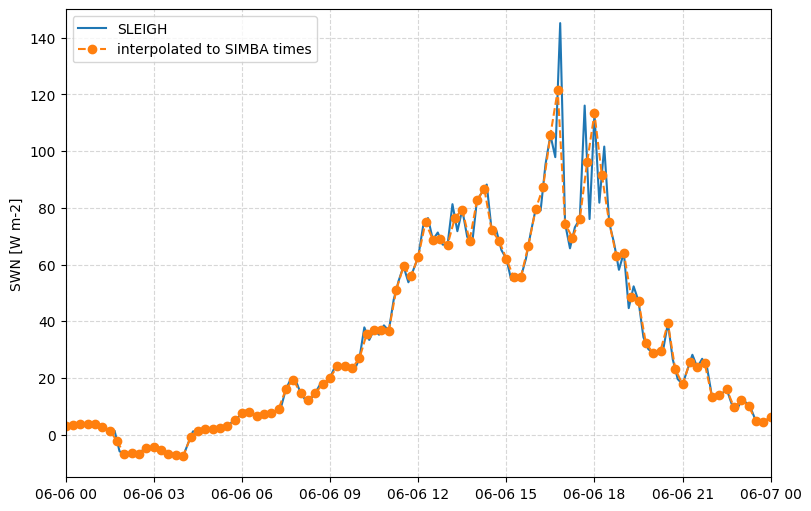

In [13]:
fig, ax = plt.subplots(1, figsize=(8,5), constrained_layout=True)
plt.plot(asfs_data_lev2['dates'], asfs_data_lev2['net_short_hemisp'], label='SLEIGH')
plt.plot(simba_dates, swn, ls='--', marker='o', label='interpolated to SIMBA times')
plt.legend(loc='best')
plt.xlim(datetime.datetime(2024,6,6), datetime.datetime(2024,6,7))
# plt.xlim(datetime.datetime(2024,6,6), datetime.datetime(2024,6,7))

plt.ylim(-15,150)
plt.grid(alpha=.5, ls='--')
plt.ylabel('SWN [W m-2]')
# plt.xlabel('seconds')
plt.show()

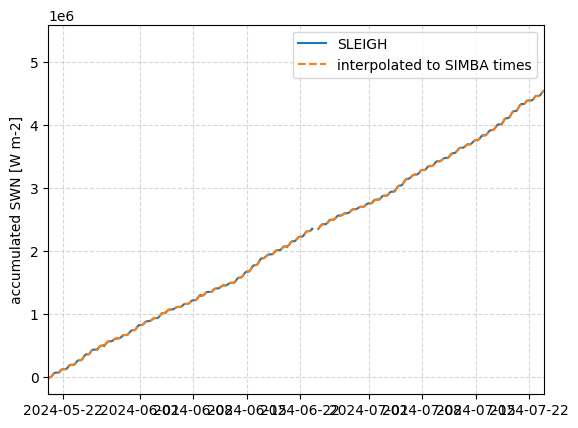

In [14]:
plt.plot(asfs_data_lev2['dates'], asfs_data_lev2['net_short_hemisp'].cumsum()*10., label='SLEIGH')
plt.plot(simba_dates, swn.cumsum()*15., ls='--', label='interpolated to SIMBA times')
plt.legend(loc='best')
plt.xlim(simba_dates[0], simba_dates[-1])
# plt.xlim(datetime.datetime(2024,6,16), datetime.datetime(2024,7,7))

plt.grid(alpha=.5, ls='--')
plt.ylabel('accumulated SWN [W m-2]')
# plt.xlabel('seconds')
plt.show()

In [15]:
mins_in_obs = 15. # minutes observations represent, ie time resolution

In [16]:
def calc_slab_swa(sfc_swn, coef, slab_top_depth, slab_depth):
    
    slab_top_swt = calc_swt_at_slab_top(sfc_swn, coef, slab_top_depth)
    slab_sw = (1. - np.exp(-coef*slab_depth))*slab_top_swt
    
    return slab_sw

In [17]:
def calc_swt_at_slab_top(sfc_swn, coef, slab_top_depth):
    # slab_top_depth in cm
    slab_swt = sfc_swn*np.exp(-coef*abs(slab_top_depth)/100.)
    return slab_swt

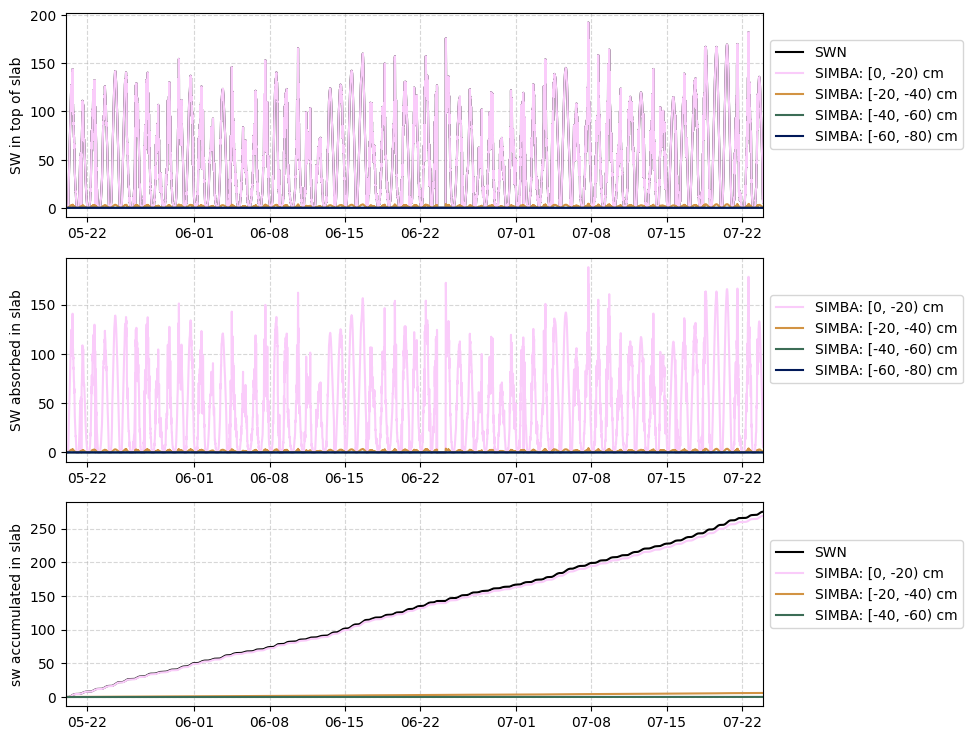

In [215]:
slab_thickness = 20 #cm

top_lev = 0
lowest_lev = 90
intervals = np.arange(-top_lev,-(lowest_lev+1),-slab_thickness) # lowest level is about where there are obs for entire season

num_colors = len(intervals)-1
cmap = cmr.batlow
color_list = decreasing_colors = [cmap(i) for i in np.linspace(0, 1, num_colors)][::-1]

interval_swa = {}
interval_swt = {}

extinc_coef = 19.
slab_thick = slab_thickness/100.


swt_intervals = {0:swn}

fig, axs = plt.subplots(3, figsize=(9,9),)

axs[0].plot(simba_dates, swn_clipped, label=f'SWN', c='k')
axs[2].plot(simba_dates, swn_clipped.cumsum()*mins_in_obs*60./10**6, label=f'SWN', c='k')

for n, (i0, i1) in enumerate(zip(intervals[:-1],intervals[1:])):

    swt_in = calc_swt_at_slab_top(swn_clipped, extinc_coef, i0)  
    swt_in.filled()
    swa_i = calc_slab_swa(swn_clipped, extinc_coef, i0, slab_thick)
    
    swt_accum = swa_i.cumsum()*mins_in_obs*60./10**6

    axs[0].plot(simba_dates, swt_in, label=f'SIMBA: [{i0}, {i1}) cm', c=color_list[n])
    axs[1].plot(simba_dates, swa_i, label=f'SIMBA: [{i0}, {i1}) cm', c=color_list[n])

    if i1!=intervals[-1]:
        axs[2].plot(simba_dates, swt_accum, label=f'SIMBA: [{i0}, {i1}) cm', c=color_list[n])

    ## SAVE FOR LATER
    interval_swa[(i0,i1)] = swa_i
    interval_swt[(i0,i1)] = swt_in


ylabels = ['SW in top of slab', 'SW absorbed in slab', 'sw accumulated in slab']
for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    
plt.show()

### Storage

In [216]:
depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_depths, simba_temps, simba_sfc)

In [217]:
dTdt_calc_from_temps_rel_sfc = temps_rel_sfc[2:] - temps_rel_sfc[:-2]

In [218]:
dTdt_rel_to_simba = simba_temps[2:] - simba_temps[:-2]

_, dTdt_calc_from_rel_to_simba = make_temps_rel_to_sfc(simba_depths, dTdt_rel_to_simba, simba_sfc[1:-1])


What's with the spike in dT/dt at 0600UTC?

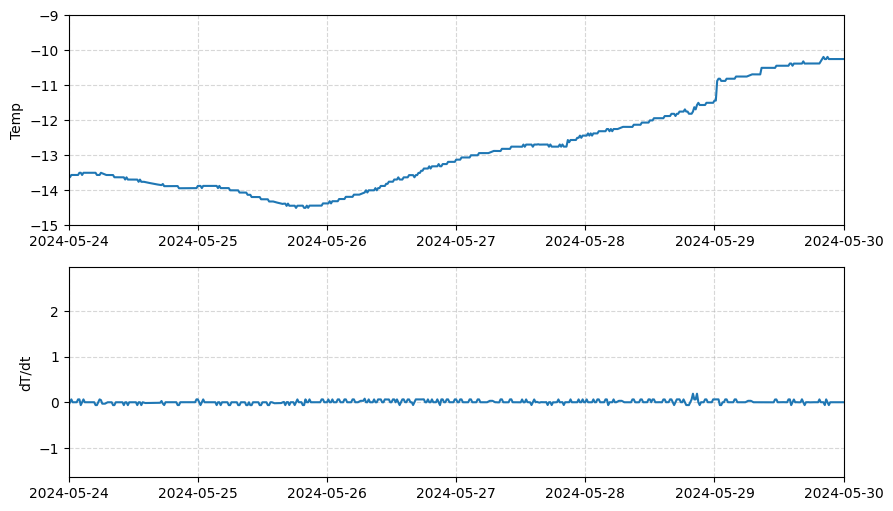

In [219]:
fig, axs = plt.subplots(2, figsize=(10,6))

d_idx = np.where(depth_rel_sfc==-40)[0]

axs[0].plot(simba_dates, temps_rel_sfc[:,d_idx])
axs[1].plot(simba_dates[1:-1], dTdt_calc_from_rel_to_simba[:,d_idx])

axs[0].set_ylim(-15,-9)

ylabels = ['Temp', 'dT/dt']
for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(ylabels[i])
    ax.set_xlim(datetime.datetime(2024,5,24),datetime.datetime(2024,5,30))

plt.show()

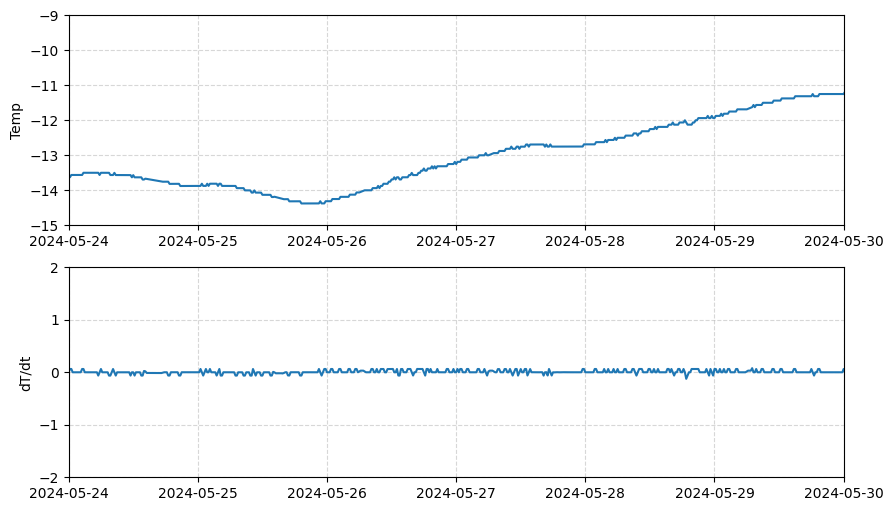

In [220]:
fig, axs = plt.subplots(2, figsize=(10,6))

d_idx = np.where(simba_depths==-40)[0]

axs[0].plot(simba_dates, simba_temps[:,d_idx])
axs[1].plot(simba_dates[1:-1], dTdt_rel_to_simba[:,d_idx])

axs[0].set_ylim(-15,-9)
# axs[0].set_ylim(-9,-7)
axs[1].set_ylim(-2,2)

ylabels = ['Temp', 'dT/dt']
for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(ylabels[i])
    ax.set_xlim(datetime.datetime(2024,5,24),datetime.datetime(2024,5,30))

plt.show()

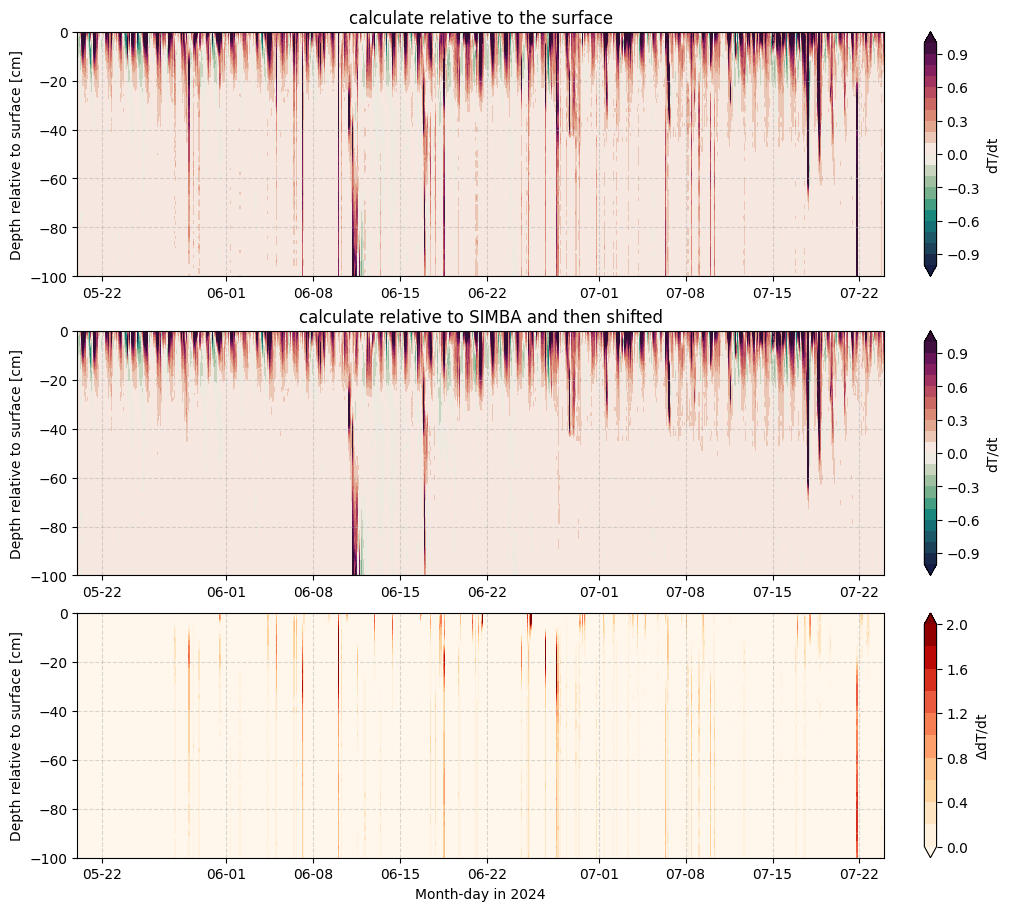

In [221]:
fig, axs = plt.subplots(3, figsize=(10,9), constrained_layout=True)

cb = axs[0].contourf(simba_dates[1:-1], depth_rel_sfc, np.swapaxes(dTdt_calc_from_temps_rel_sfc,0,1), cmap=cmocean.cm.curl,
                  levels=np.arange(-1,1.01,.1), extend='both')
plt.colorbar(cb, ax=axs[0], label='dT/dt')
axs[0].set_title('calculate relative to the surface')

cb = axs[1].contourf(simba_dates[1:-1], depth_rel_sfc, np.swapaxes(dTdt_calc_from_rel_to_simba,0,1), cmap=cmocean.cm.curl, 
                  levels=np.arange(-1,1.01,.1), extend='both')
plt.colorbar(cb, ax=axs[1], label='dT/dt')
axs[1].set_title('calculate relative to SIMBA and then shifted')


dTdt_diff = dTdt_calc_from_temps_rel_sfc - dTdt_calc_from_rel_to_simba
cb = axs[2].contourf(simba_dates[1:-1], depth_rel_sfc, np.swapaxes(dTdt_diff,0,1), cmap=plt.cm.OrRd,
                    levels=np.arange(0,2.01,.2), extend='both')
plt.colorbar(cb, ax=axs[2], label='$\Delta$dT/dt')

for ax in axs.ravel():
    ax.set_ylabel('Depth relative to surface [cm]')
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(-100,0)
    ax.xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')
# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

Compare how much the order of operations matters

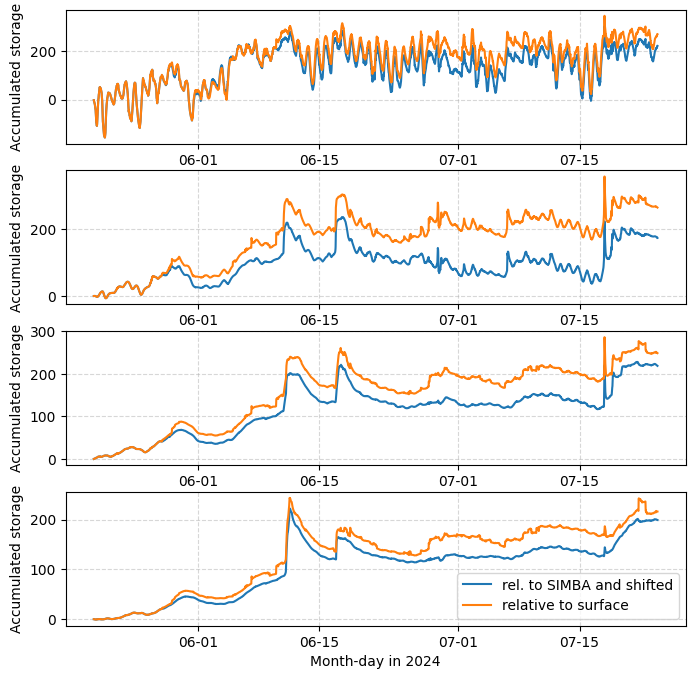

In [222]:
dTdts = [dTdt_calc_from_rel_to_simba, dTdt_calc_from_temps_rel_sfc]
labels = ['rel. to SIMBA and shifted', 'relative to surface']

intervals = np.arange(0,-91,-slab_thickness)
fig, axs = plt.subplots(len(intervals)-1, figsize=(8,(len(intervals)-1)*2))

for i, dTt in enumerate(dTdts): 
    
    for n, (i0, i1) in enumerate(zip(intervals[:-1],intervals[1:])):
        int_idx = np.where((depth_rel_sfc<=i0)&(depth_rel_sfc>i1))[0]
        
        axs[n].plot(simba_dates[1:-1], dTt[:,int_idx].sum(axis=1).cumsum(), label=labels[i])

        # lower_layers_for_sum = []
        # for i in range(lower_layer_temps.shape[1]-1):
        #     i_layr_temp_diff = lower_layer_temps[2:,i] - lower_layer_temps[:-2,i] + lower_layer_temps[2:,i+1] - lower_layer_temps[:-2,i+1]
        #     lower_layers_for_sum.append(dz*i_layr_temp_diff/2.)
    
        # lower_layers_for_sum = np.array(lower_layers_for_sum)

for ax in axs.ravel():
    ax.set_ylabel('Accumulated storage')
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylim(-100,0)
    ax.xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')
axs[-1].legend(loc='best')
# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

In [223]:
c_i = 2.1*10**-3 # MJ kg-1 C-1
# d_s = .2 # m
dz = 0.02 # m

mins_in_obs = 15 # time resolution of SIMBA
secs_in_min = 60. # seconds

secs_in_obs = mins_in_obs*secs_in_min

time_diff = simba_seconds[2:] - simba_seconds[:-2]


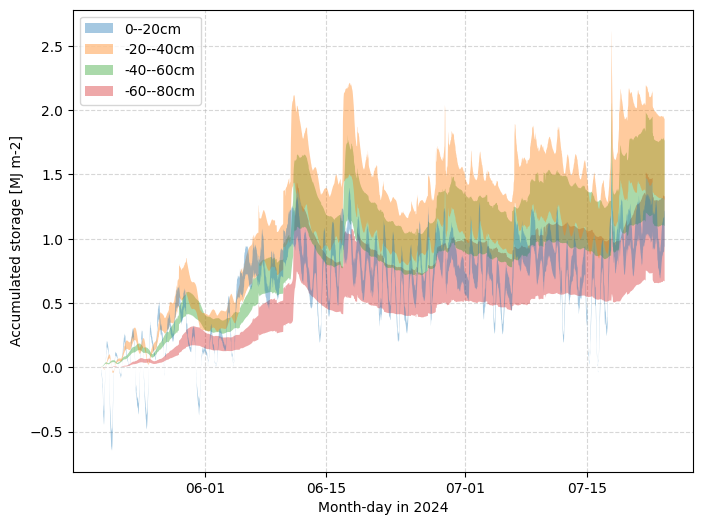

In [224]:
fig, ax = plt.subplots(1, figsize=(8,6))

for n, (d0, d1) in enumerate(zip(intervals[:-1], intervals[1:])):

    ## calculate storage
    lower_density_timeseries = get_snowpit_hi_lo_density_timeseries(-d0, -d1)
    lower_rho_lo = lower_density_timeseries['lo']
    lower_rho_hi = lower_density_timeseries['hi']
    
    lower_layer_idx = np.where((depth_rel_sfc<=d0)&(depth_rel_sfc>d1))[0]
    lower_layer_temps = np.squeeze(temps_rel_sfc[:,lower_layer_idx])

    arr_layers = lower_layer_temps[2:,1:] - lower_layer_temps[:-2,1:] + lower_layer_temps[2:,:-1] - lower_layer_temps[:-2,:-1]
    arr_layers = dz*arr_layers.sum(axis=1)/2.
    
    lower_storage_arr_layers = c_i*lower_rho_lo[1:-1]*arr_layers/(time_diff)
    upper_storage_arr_layers = c_i*lower_rho_hi[1:-1]*arr_layers/(time_diff)


    ax.fill_between(simba_dates[1:-1], lower_storage_arr_layers.cumsum()*secs_in_obs, \
                        upper_storage_arr_layers.cumsum()*secs_in_obs, label=f'{d0}-{d1}cm', zorder=5-n, alpha=.4)
    
# for ax in axs.ravel():
ax.set_ylabel('Accumulated storage [MJ m-2]')
ax.grid(alpha=.5, ls='--')
# ax.set_ylim(-100,0)
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.legend(loc='best')

# plt.xlim(dt(2024,5,18),dt(2024,6,15))
# plt.ylim(-1,2)
plt.show()

Try alternative of calculating differences relative to SIMBA and then getting upper Xcm

In [225]:
dTdt_2sided = simba_temps[2:,1:] - simba_temps[:-2,1:] + simba_temps[2:,:-1] - simba_temps[:-2,:-1]
_, dTdt_2sided_rel_to_sfc = make_temps_rel_to_sfc(simba_depths[1:], dTdt_2sided, simba_sfc[1:-1]) # should it be 1: or :-1?

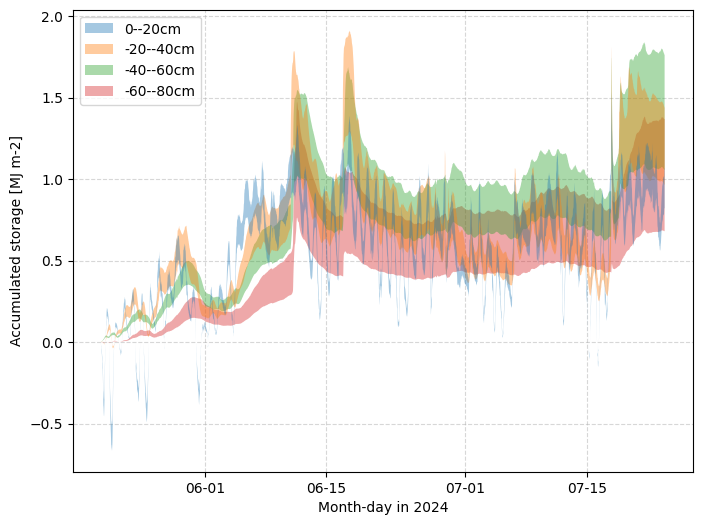

In [226]:
interval_storage = {}

fig, ax = plt.subplots(1, figsize=(8,6))

for n, (d0, d1) in enumerate(zip(intervals[:-1], intervals[1:])):

    ## calculate storage
    lower_density_timeseries = get_snowpit_hi_lo_density_timeseries(-d0, -d1)
    lower_rho_lo = lower_density_timeseries['lo']
    lower_rho_hi = lower_density_timeseries['hi']
    
    lower_layer_idx = np.where((depth_rel_sfc<=d0)&(depth_rel_sfc>d1))[0]
    lower_layer_dTdt = np.squeeze(dTdt_2sided_rel_to_sfc[:,lower_layer_idx])

    arr_layers = dz*lower_layer_dTdt.sum(axis=1)/2.
    
    lower_storage_arr_layers = c_i*lower_rho_lo[1:-1]*arr_layers/(time_diff)
    upper_storage_arr_layers = c_i*lower_rho_hi[1:-1]*arr_layers/(time_diff)


    ax.fill_between(simba_dates[1:-1], lower_storage_arr_layers.cumsum()*secs_in_obs, \
                        upper_storage_arr_layers.cumsum()*secs_in_obs, label=f'{d0}-{d1}cm', zorder=5-n, alpha=.4)
    
    interval_storage[(d0, d1)] = {'lo':lower_storage_arr_layers*10.**6, 'hi':upper_storage_arr_layers*10.**6}

# for ax in axs.ravel():
ax.set_ylabel('Accumulated storage [MJ m-2]')
ax.grid(alpha=.5, ls='--')
# ax.set_ylim(-100,0)
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.legend(loc='best')

# plt.xlim(dt(2024,5,18),dt(2024,6,15))
# plt.ylim(-1,2)
plt.show()   

0 -20
-20 -40
-40 -60
-60 -80


/tmp/ipykernel_116777/1660435700.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


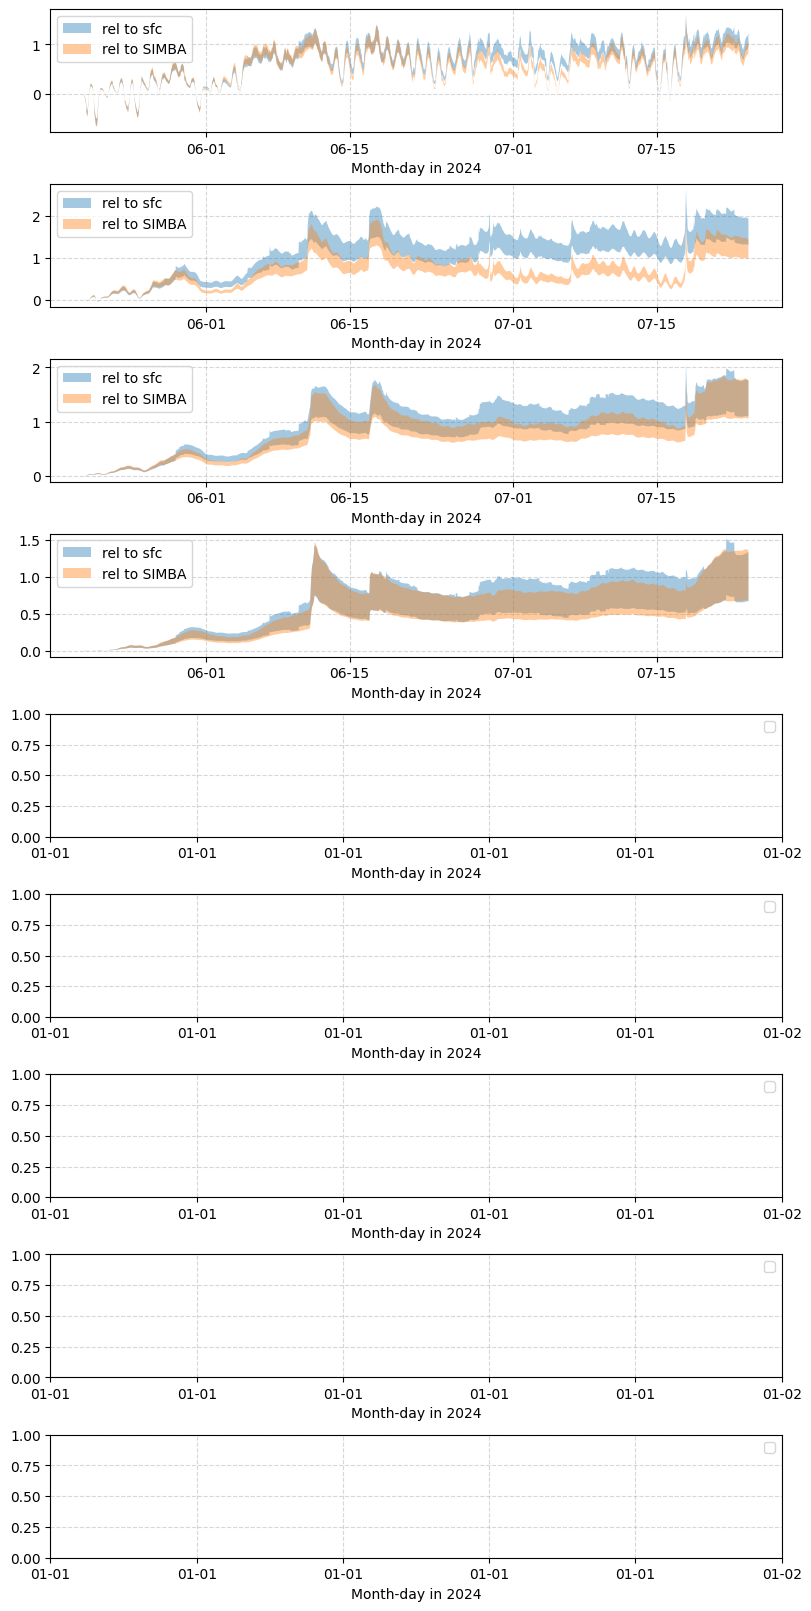

In [227]:
# COMPARE THEM DIRECTLY
intervals = np.arange(0,-91,-slab_thickness)

fig, axs = plt.subplots(9, figsize=(8,16), constrained_layout=True)

for n, (d0, d1) in enumerate(zip(intervals[:-1], intervals[1:])):
    print(d0,d1)
    ## calculate storage
    lower_density_timeseries = get_snowpit_hi_lo_density_timeseries(-d0, -d1)
    lower_rho_lo = lower_density_timeseries['lo']
    lower_rho_hi = lower_density_timeseries['hi']
    
    lower_layer_idx = np.where((depth_rel_sfc<=d0)&(depth_rel_sfc>d1))[0]
    lower_layer_temps = np.squeeze(temps_rel_sfc[:,lower_layer_idx])

    arr_layers = lower_layer_temps[2:,1:] - lower_layer_temps[:-2,1:] + lower_layer_temps[2:,:-1] - lower_layer_temps[:-2,:-1]
    arr_layers = dz*arr_layers.sum(axis=1)/2.
    
    lower_storage_arr_layers = c_i*lower_rho_lo[1:-1]*arr_layers/(time_diff)
    upper_storage_arr_layers = c_i*lower_rho_hi[1:-1]*arr_layers/(time_diff)


    axs[n].fill_between(simba_dates[1:-1], lower_storage_arr_layers.cumsum()*secs_in_obs, \
                        upper_storage_arr_layers.cumsum()*secs_in_obs, label='rel to sfc', zorder=5-n, alpha=.4)


    lower_layer_dTdt = np.squeeze(dTdt_2sided_rel_to_sfc[:,lower_layer_idx])

    arr_layers = dz*lower_layer_dTdt.sum(axis=1)/2.
    
    lower_storage_arr_layers = c_i*lower_rho_lo[1:-1]*arr_layers/(time_diff)
    upper_storage_arr_layers = c_i*lower_rho_hi[1:-1]*arr_layers/(time_diff)


    axs[n].fill_between(simba_dates[1:-1], lower_storage_arr_layers.cumsum()*secs_in_obs, \
                        upper_storage_arr_layers.cumsum()*secs_in_obs, label='rel to SIMBA', zorder=5-n, alpha=.4)

    
for ax in axs.ravel():
    # ax.set_ylabel('Accumulated storage [MJ m-2]')
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylim(-100,0)
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='best')

# plt.xlim(dt(2024,5,18),dt(2024,6,15))
# plt.ylim(-1,2)
plt.show()


#### calculate storage over 20cm layer for MIchael's paper

In [61]:
d0 = 0
d1 = -20

lower_density_timeseries = get_snowpit_hi_lo_density_timeseries(-d0, -d1)

lower_rho_lo = lower_density_timeseries['lo']
lower_rho_hi = lower_density_timeseries['hi']
lower_layer_idx = np.where((depth_rel_sfc<=d0)&(depth_rel_sfc>d1))[0]
lower_layer_temps = np.squeeze(temps_rel_sfc[:,lower_layer_idx])

arr_layers = lower_layer_temps[2:,1:] - lower_layer_temps[:-2,1:] + lower_layer_temps[2:,:-1] - lower_layer_temps[:-2,:-1]
arr_layers = dz*arr_layers.sum(axis=1)/2.

lower_storage_arr_layers = c_i*lower_rho_lo[1:-1]*arr_layers/(time_diff)
upper_storage_arr_layers = c_i*lower_rho_hi[1:-1]*arr_layers/(time_diff)

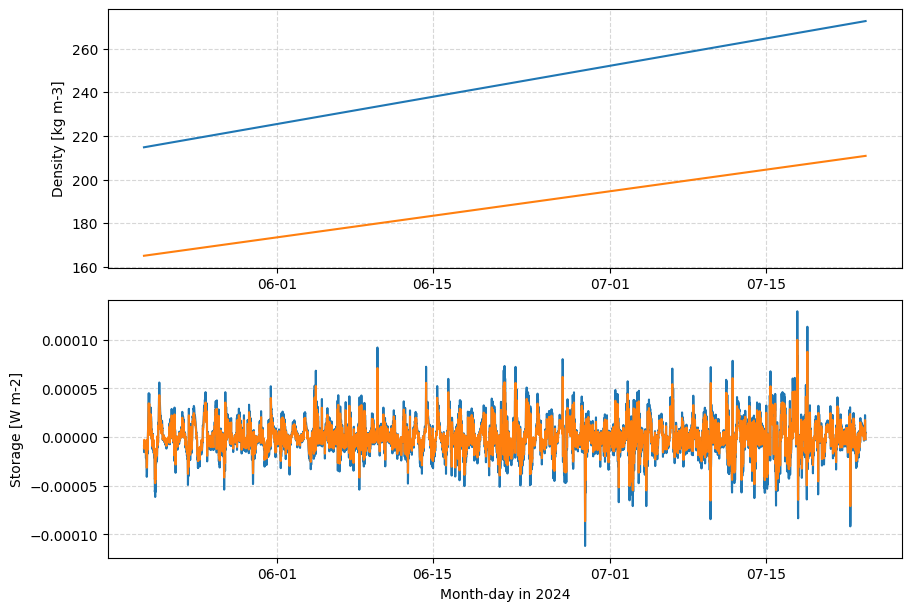

In [63]:
fig, axs = plt.subplots(2, figsize=(9,6), constrained_layout=True)
axs[0].plot(simba_dates, lower_rho_hi)
axs[0].plot(simba_dates, lower_rho_lo)

axs[1].plot(simba_dates[1:-1], upper_storage_arr_layers)
axs[1].plot(simba_dates[1:-1], lower_storage_arr_layers)

axs[0].set_ylabel('Density [kg m-3]')
axs[1].set_ylabel('Storage [W m-2]')

for ax in axs.ravel():
    ax.grid(alpha=.5, ls='--')
    ax.xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [65]:
with open('Raven_2024_20cm_storage_range_20251111.csv', 'w', ) as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    myfile.write("{},{}\n".format("Dates", "Low storage [W m-2]", "High storage [W m-2]", "Low Density [kg m-3]", "High Density [kg m-3]"))
    for item1, item2, item3, item4, item5 in zip(simba_dates[1:-1], lower_storage_arr_layers, upper_storage_arr_layers, lower_rho_lo[1:-1], lower_rho_hi[1:-1]):
        wr.writerow([item1, item2, item3, item4, item5])

### conduction

In [228]:
dT_dz = np.gradient(simba_temps, simba_depths, axis=1)

heights_rel_to_sfc = np.repeat(simba_depths.copy()[np.newaxis,:], simba_temps.shape[0], axis=0)

sfc_2d = np.ma.repeat(simba_sfc[:,np.newaxis], simba_temps.shape[1], axis=1)
heights_rel_to_sfc = heights_rel_to_sfc-sfc_2d


temporary_grad = np.ma.masked_where(heights_rel_to_sfc>0, dT_dz)# temporary temperature

dT_dz_rel_to_sfc = []

m = 100 # size of 

for i in range(temporary_grad.shape[0]):
    temp_i = temporary_grad[i,:-1]
    sub_t = temp_i[~temp_i.mask]

    sub_t_filled = np.ma.concatenate( (sub_t, np.full(int(m-sub_t.count()), -999 )) )
    dT_dz_rel_to_sfc.append(sub_t_filled)
    
dT_dz_rel_to_sfc = np.ma.masked_equal(dT_dz_rel_to_sfc, -999)

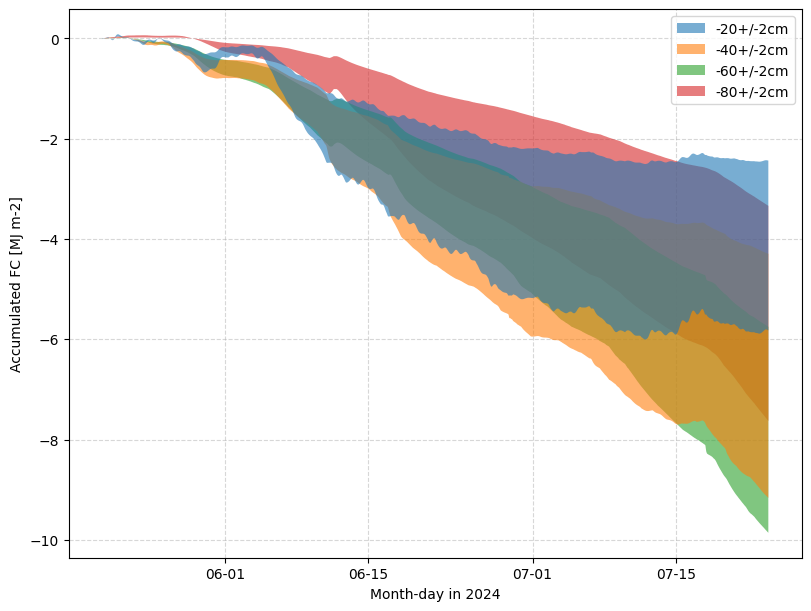

In [229]:
# intervals = np.arange(0,-91,-10)
interval_FC = {}

fig, ax = plt.subplots(1, figsize=(8,6), constrained_layout=True)

for n, (d0, d1) in enumerate(zip(intervals[:-1], intervals[1:])):

    ## calculate storage
    lower_density_timeseries = get_snowpit_hi_lo_density_timeseries(d0, d1)
    lower_rho_lo = lower_density_timeseries['lo']
    lower_rho_hi = lower_density_timeseries['hi']

    
    lower_layer_idx = np.where( (depth_rel_sfc>=d1)&(depth_rel_sfc<=d0))[0]
    lower_layer_temps = np.squeeze(temps_rel_sfc[:,lower_layer_idx])
    
    
    ## calculate conduction
    d_level_T = temps_rel_sfc[:,np.where(depth_rel_sfc==d1)[0]]+273.15

    d_pad = 2
    FC_density_timeseries = get_snowpit_hi_lo_density_timeseries(-d1-d_pad, -d1+d_pad)
    rho_lo_FC = FC_density_timeseries['lo']
    rho_hi_FC = FC_density_timeseries['hi']


    ks_lo = calc_k_approx(np.squeeze(d_level_T), np.squeeze(rho_lo_FC))
    ks_hi = calc_k_approx(np.squeeze(d_level_T), np.squeeze(rho_hi_FC))

    d_level_dTdz = np.squeeze(dT_dz_rel_to_sfc[:,np.where(depth_rel_sfc==d1)[0]])
    
    FC_d_level_lo = -ks_lo*d_level_dTdz*100. # convert from cm to m 
    FC_d_level_hi = -ks_hi*d_level_dTdz*100. # convert from cm to m 
    
    FC_lo_cum = FC_d_level_lo.cumsum()*secs_in_obs/10.**6
    FC_hi_cum = FC_d_level_hi.cumsum()*secs_in_obs/10.**6

    ax.fill_between(simba_dates, FC_lo_cum, FC_hi_cum, label=f'{d1}+/-{d_pad}cm', #color=color_list[n], \
                        zorder=5-n, alpha=.6)

    interval_FC[(d1)] = {'hi':FC_d_level_hi, 'lo':FC_d_level_lo}

# for ax in axs.ravel():
ax.set_ylabel('Accumulated FC [MJ m-2]')
ax.grid(alpha=.5, ls='--')
# ax.set_ylim(-100,0)
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.legend(loc='best')

# plt.xlim(dt(2024,5,18),dt(2024,6,15))
# plt.ylim(-1,2)
plt.show()


## plot calculated fluxes

In [230]:
print(intervals)
interval_FC_div = {}

for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
    if d0==0:
        continue

    interval_FC_div[(d0, d1)] = {}
    
    for density_lev_top in ['hi','lo']:
        FC_top = interval_FC[d0][density_lev_top]
        
        for density_lev_bot in ['hi','lo']:
            FC_bot = interval_FC[d1][density_lev_bot]
            print((density_lev_top, density_lev_bot))
            interval_FC_div[(d0, d1)][(density_lev_top, density_lev_bot)] = -(FC_top - FC_bot) ## think it should be negative because FC is relative to the surface but we want FC relative to the slab?

[  0 -20 -40 -60 -80]
('hi', 'hi')
('hi', 'lo')
('lo', 'hi')
('lo', 'lo')
('hi', 'hi')
('hi', 'lo')
('lo', 'hi')
('lo', 'lo')
('hi', 'hi')
('hi', 'lo')
('lo', 'hi')
('lo', 'lo')


In [231]:
interval_flx_dics = {'SWA':interval_swa, 'S':interval_storage, 'FC':interval_FC, 'FC_div':interval_FC_div}

for flx_dic in interval_flx_dics:
    print(flx_dic, interval_flx_dics[flx_dic].keys())
    print()

SWA dict_keys([(np.int64(0), np.int64(-20)), (np.int64(-20), np.int64(-40)), (np.int64(-40), np.int64(-60)), (np.int64(-60), np.int64(-80))])

S dict_keys([(np.int64(0), np.int64(-20)), (np.int64(-20), np.int64(-40)), (np.int64(-40), np.int64(-60)), (np.int64(-60), np.int64(-80))])

FC dict_keys([np.int64(-20), np.int64(-40), np.int64(-60), np.int64(-80)])

FC_div dict_keys([(np.int64(-20), np.int64(-40)), (np.int64(-40), np.int64(-60)), (np.int64(-60), np.int64(-80))])



In [234]:
interval_flx_dics['resid'] = {}
interval_flx_dics['resid_no_sw'] = {}
interval_flx_dics['resid_less_sw'] = {}

for d0 in interval_flx_dics['FC'].keys():
    if d0 not in [0, -90, -80]:
        # d1 = d0-10
        d1 = d0-slab_thickness
        interval_flx_dics['resid'][(d0,d1)] = {}
        interval_flx_dics['resid_no_sw'][(d0,d1)] = {}
        interval_flx_dics['resid_less_sw'][(d0,d1)] = {}

        for uncert_FC_0 in ['hi', 'lo']:
            for uncert_FC_1 in ['hi', 'lo']:
                for uncert_S in ['hi', 'lo']:

                    level_resid = interval_flx_dics['FC_div'][(d0,d1)][(uncert_FC_0, uncert_FC_1)][1:-1] + interval_flx_dics['SWA'][(d0,d1)][1:-1] - interval_flx_dics['S'][(d0,d1)][uncert_S]
                    interval_flx_dics['resid'][(d0,d1)][(uncert_FC_0, uncert_FC_1, uncert_S)] = -level_resid # minus to make it into source/sink like Pfeffer and Humphrey not energy for melt like at sfc
            
                    level_resid_no_sw = interval_flx_dics['FC_div'][(d0,d1)][(uncert_FC_0, uncert_FC_1)][1:-1] - interval_flx_dics['S'][(d0,d1)][uncert_S]
                    interval_flx_dics['resid_no_sw'][(d0,d1)][(uncert_FC_0, uncert_FC_1, uncert_S)] = -level_resid_no_sw
            
                    level_resid_no_sw = interval_flx_dics['FC_div'][(d0,d1)][(uncert_FC_0, uncert_FC_1)][1:-1] - interval_flx_dics['S'][(d0,d1)][uncert_S] + .5*interval_flx_dics['SWA'][(d0,d1)][1:-1]
                    interval_flx_dics['resid_less_sw'][(d0,d1)][(uncert_FC_0, uncert_FC_1, uncert_S)] = -level_resid_no_sw

In [235]:
for flx in ['resid', 'FC_div']:
    for d0, d1 in interval_flx_dics[flx].keys():
        interval_resid = []
        for uncert_FC_0 in ['hi', 'lo']:
            for uncert_FC_1 in ['hi', 'lo']:
                if flx=='FC_div':
                    interval_resid.append(interval_flx_dics[flx][(d0,d1)][(uncert_FC_0, uncert_FC_1)])
                else:
                    for uncert_S in ['hi', 'lo']:
                        interval_resid.append(interval_flx_dics[flx][(d0,d1)][(uncert_FC_0, uncert_FC_1, uncert_S)])
    
        interval_resid_arr = np.ma.masked_invalid(interval_resid)
        interval_flx_dics[flx][(d0,d1)]['hi'] = interval_resid_arr.min(axis=0)
        interval_flx_dics[flx][(d0,d1)]['lo'] = interval_resid_arr.max(axis=0)

In [236]:
print(type(interval_flx_dics['resid'][(d0,d1)]['hi']))
print(type(interval_flx_dics['resid'][(d0,d1)][(uncert_FC_0, uncert_FC_1, uncert_S)]))

<class 'numpy.ma.MaskedArray'>
<class 'numpy.ma.MaskedArray'>


Start with basic plot of everything, then go to accumulated values and making it more readable!

IndexError: index 5 is out of bounds for axis 0 with size 5

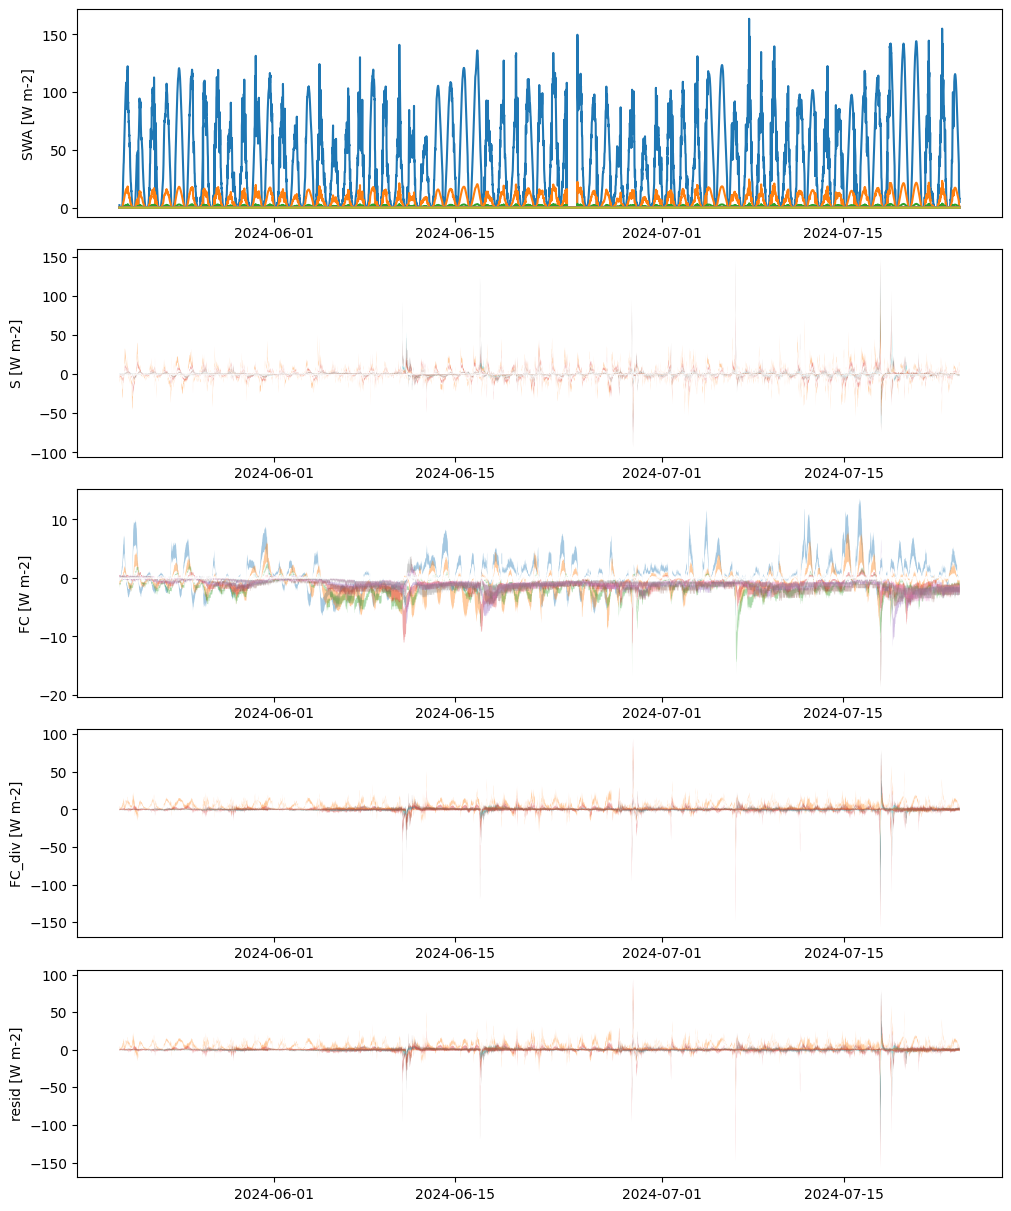

In [163]:
fig, axs = plt.subplots(5, figsize=(10,12), constrained_layout=True)

for i, flx_key in enumerate(interval_flx_dics):
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'{flx_key} [W m-2]')
    
    for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage, residual)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.4)
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.4)
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.4)
            
        # some levels aren't in the dictionary
        else:
            continue

# fix ylabels!!!
# ylabels = ['dT/dt [C/?]', 'Downward dT/dz [$^o$C/cm]', 'storage [MJ m$^{-2}$]', 'conduciton [MJ m$^{-2}$]']

for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))

    
axs[-1].set_xlabel('Month-day in 2024')


labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075,.875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

In [242]:
num_colors = len(intervals)-1
melt_colors = [cmap(i) for i in np.linspace(0, 1, num_colors)][::-1]

In [165]:
skinT_sfc_timestepsskin_temp = asfs_data_lev2['skin_temp']-273.15
skinT_sfc_timesteps = interpolate_and_mask(skinT_sfc_timestepsskin_temp, sleigh_seconds, simba_seconds)
skinT_sfc_timesteps = np.ma.masked_outside(skinT_sfc_timesteps, -30, 5)

In [166]:
tksin_uncert = 0.4
tskin_melt_indices = np.ma.clump_unmasked(np.ma.masked_less(skinT_sfc_timesteps, -tksin_uncert))
print(len(tskin_melt_indices))

30


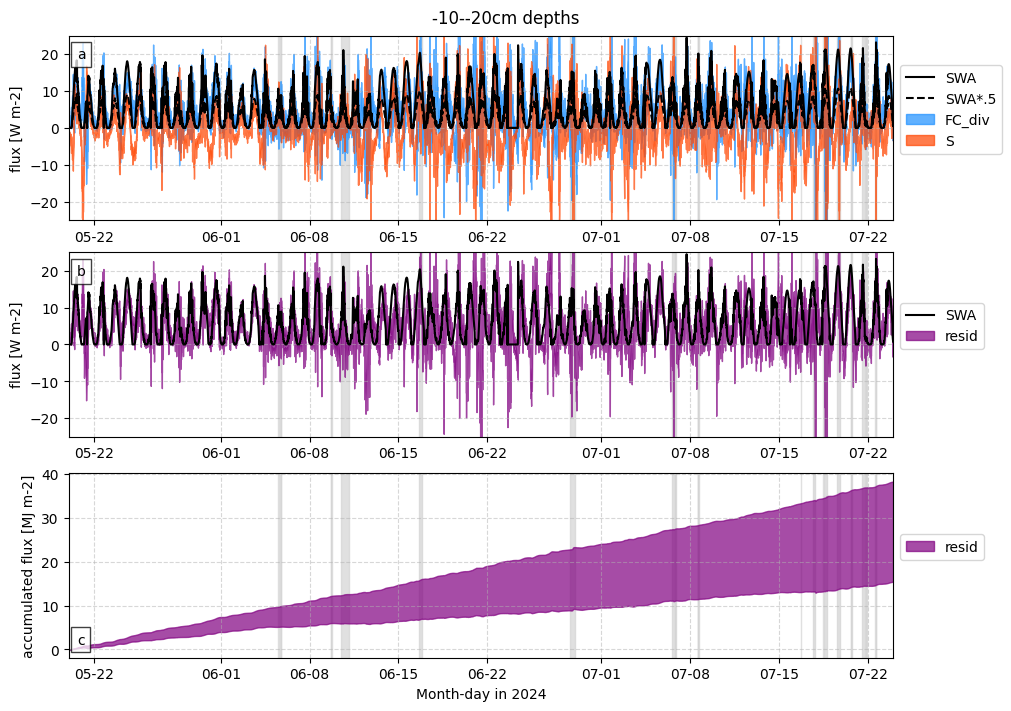

In [167]:
fig, axs = plt.subplots(3, figsize=(10,7), constrained_layout=True)

d0, d1 = -10, -20

fig.suptitle(f'{d0}-{d1}cm depths')

for flx_key, c in zip(['SWA','FC_div','S','resid','resid_no_sw','resid_less_sw'],['k','dodgerblue','orangered','purple','green','c']):
    var_dic = interval_flx_dics[flx_key]
    if 'resid' in flx_key:
        i=1
    else:
        i=0
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
    if (d0,d1) in var_dic:
        if 'hi' in var_dic[(d0,d1)]:
            if 'resid' in flx_key:
                axs[2].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                    var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.7,
                               label=flx_key, color=c)
            try:
                axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                   label=flx_key, color=c)
                    
            except:
                axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                   label=flx_key, color=c)
        else:
            if flx_key=='SWA':
                axs[0].plot(simba_dates, var_dic[(d0,d1)], label=flx_key, color=c)
                axs[0].plot(simba_dates, .5*var_dic[(d0,d1)], label='SWA*.5', color=c, ls='--')

                axs[1].plot(simba_dates, var_dic[(d0,d1)], label=flx_key, color=c)
            
    # FC is only at a specific level
    elif d0 in var_dic:
        axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=flx_key, 
                            color=c)
        
    # some levels aren't in the dictionary
    else:
        continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    # ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,5,30))
    # ax.set_xlim(datetime.datetime(2024,6,20),datetime.datetime(2024,6,30))

    if i==2:
        ax.set_ylabel('accumulated flux [MJ m-2]')
    else:
        ax.set_ylabel('flux [W m-2]')
    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

axs[0].set_ylim(-25,25)
axs[1].set_ylim(-25,25)

# axs[4].set_ylim(-20,30)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

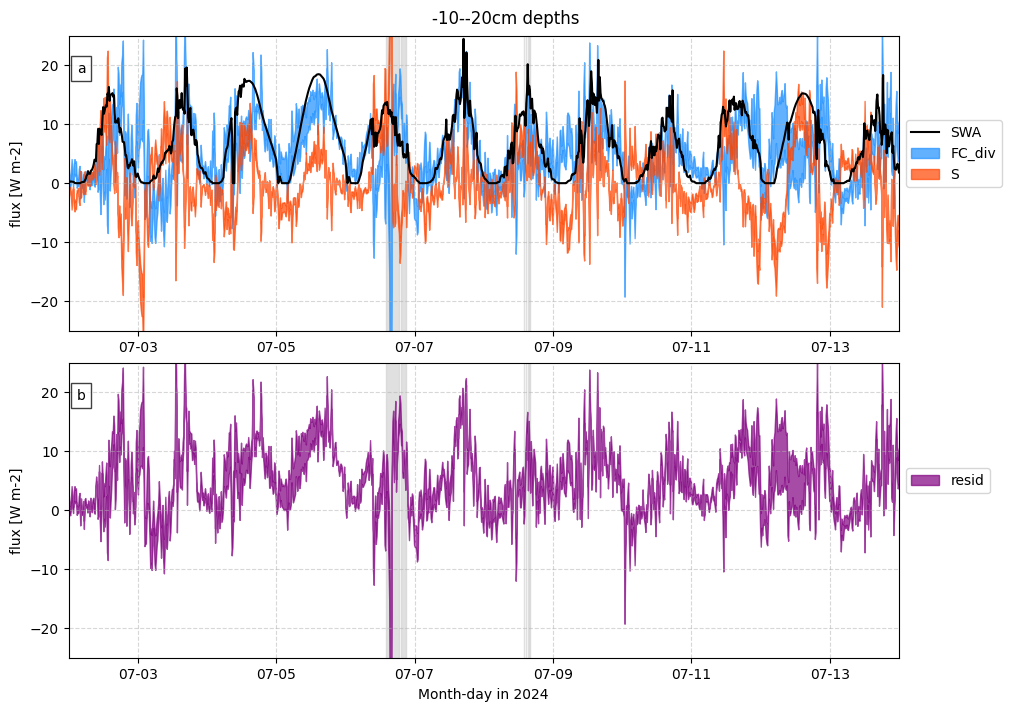

In [168]:
fig, axs = plt.subplots(2, figsize=(10,7), constrained_layout=True)

d0, d1 = -10, -20

fig.suptitle(f'{d0}-{d1}cm depths')

for flx_key, c in zip(['SWA','FC_div','S','resid'],['k','dodgerblue','orangered','purple']):
    var_dic = interval_flx_dics[flx_key]
    if flx_key=='resid':
        i=1
    else:
        i=0
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
    if (d0,d1) in var_dic:
        if 'hi' in var_dic[(d0,d1)]:
            try:
                axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                   label=flx_key, color=c)
            except:
                axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                   label=flx_key, color=c)
        else:
            axs[i].plot(simba_dates, var_dic[(d0,d1)], label=flx_key, color=c)
            
    # FC is only at a specific level
    elif d0 in var_dic:
        axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=flx_key, 
                            color=c)
        
    # some levels aren't in the dictionary
    else:
        continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    # ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    ax.set_xlim(datetime.datetime(2024,7,2),datetime.datetime(2024,7,14))
    ax.set_ylabel('flux [W m-2]')
    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

axs[0].set_ylim(-25,25)
axs[1].set_ylim(-25,25)

# axs[4].set_ylim(-20,30)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

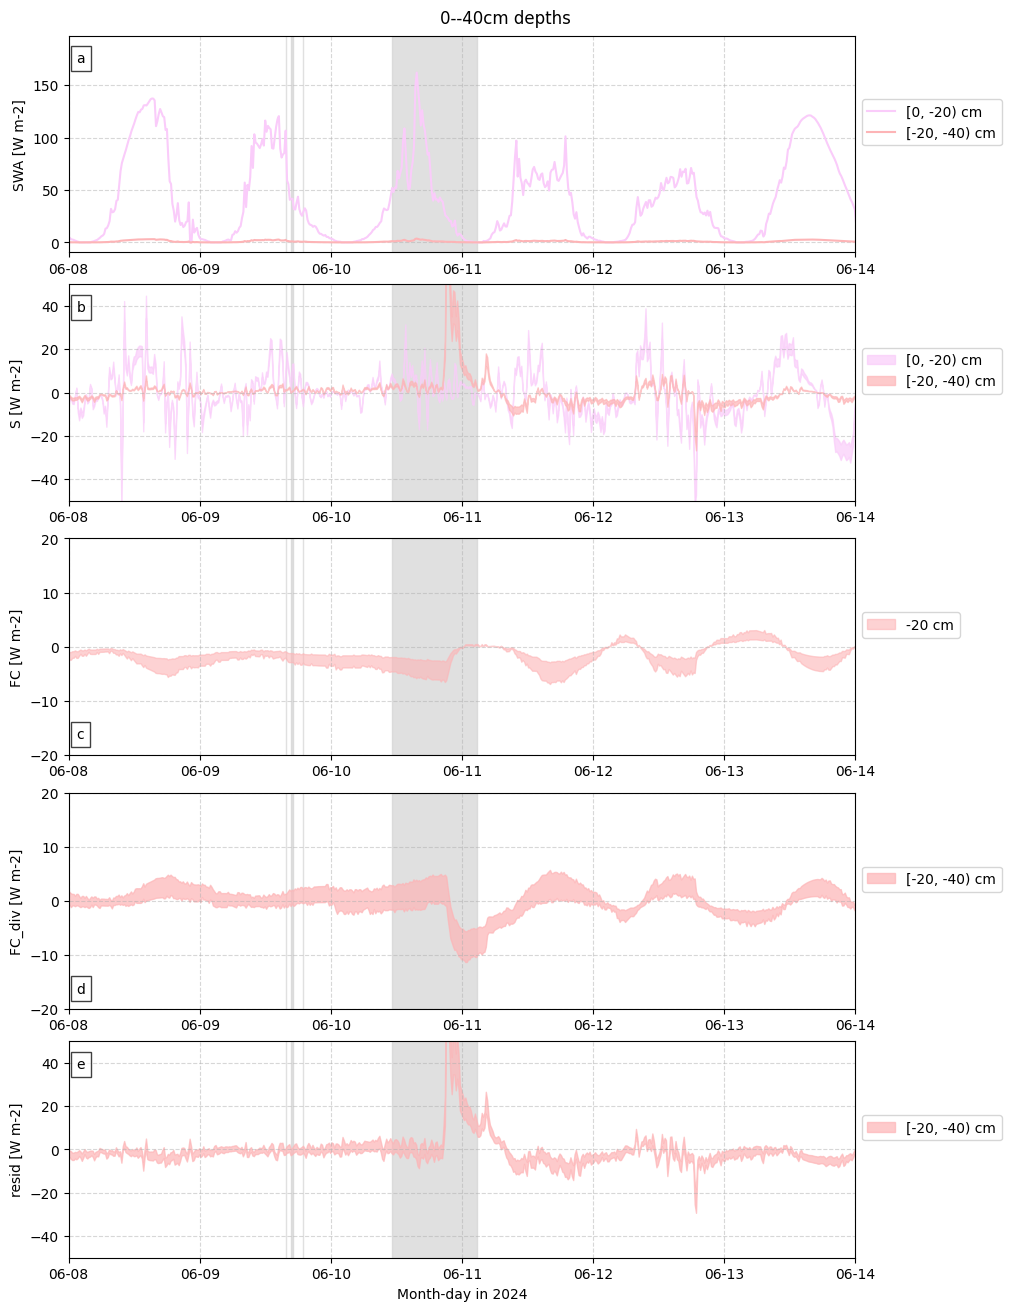

In [241]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

intervals_short = intervals[np.where(intervals>=-50)]

melt_colors_short = melt_colors[:len(intervals_short)]
fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'{flx_key} [W m-2]')
    for n, (d0, d1) in enumerate(zip(intervals_short[:-1],intervals_short[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)], label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=f'{d0} cm', 
                                color=melt_colors_short[n])
            
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    # ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    # ax.set_xlim(datetime.datetime(2024,6,12),datetime.datetime(2024,6,14))
    # ax.set_xlim(datetime.datetime(2024,7,8),datetime.datetime(2024,7,24))
    ax.set_xlim(datetime.datetime(2024,6,8),datetime.datetime(2024,6,14))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

axs[1].set_ylim(-50,50)
axs[3].set_ylim(-20,20)
axs[2].set_ylim(-20,20)

axs[4].set_ylim(-50,50)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

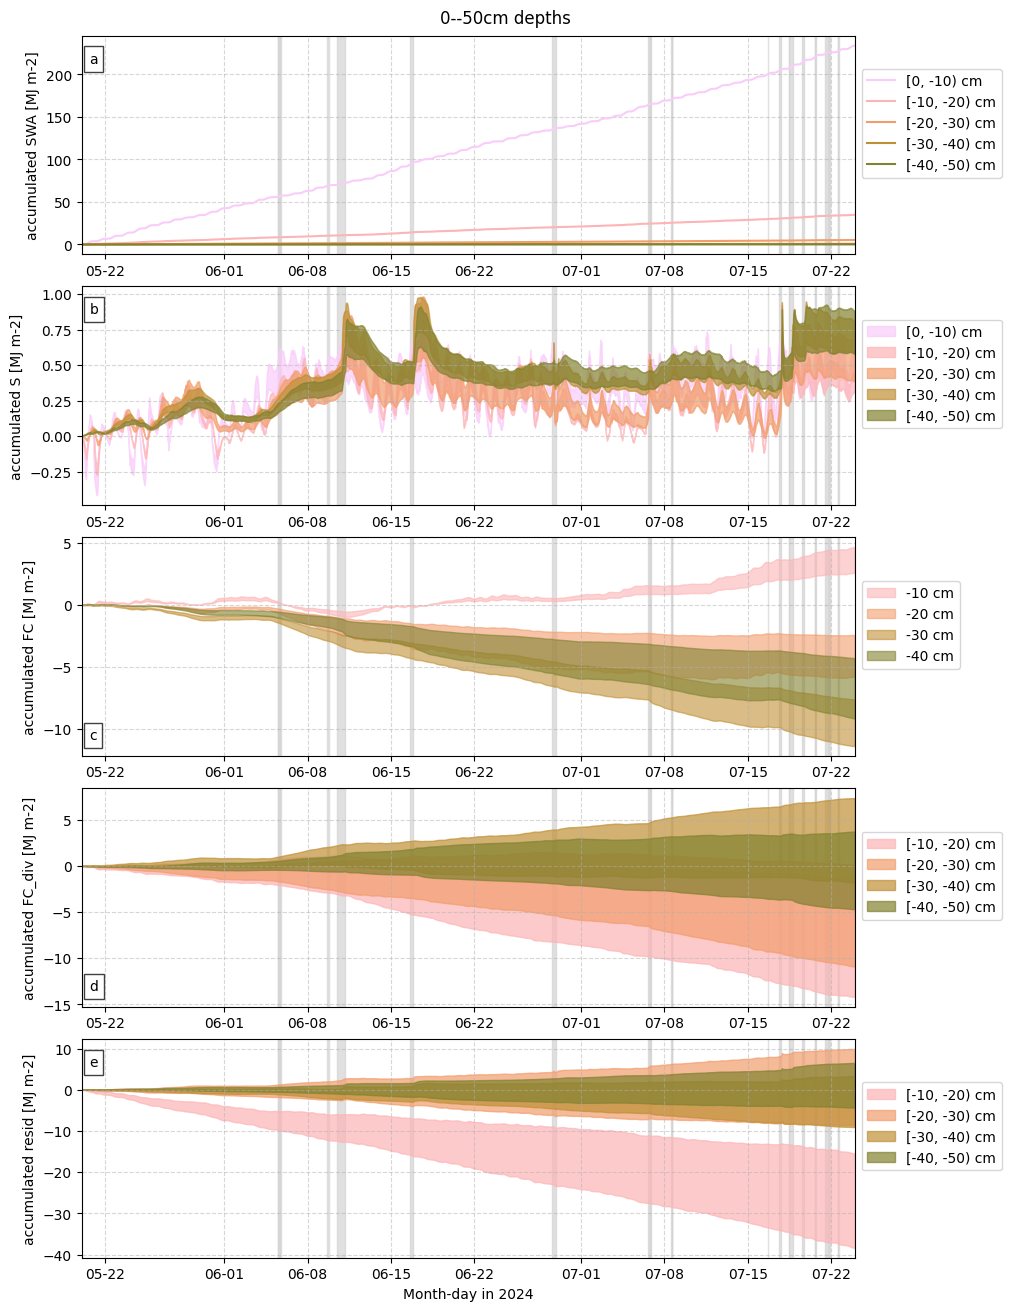

In [206]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

intervals_short = intervals[np.where(intervals>=-50)]

melt_colors_short = melt_colors[:len(intervals_short)]
fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'accumulated {flx_key} [MJ m-2]')
    for n, (d0, d1) in enumerate(zip(intervals_short[:-1],intervals_short[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)].cumsum()*secs_in_obs/10**6, 
                            label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'].cumsum()*secs_in_obs/10**6, 
                                var_dic[d0]['hi'].cumsum()*secs_in_obs/10**6, alpha=.6, label=f'{d0} cm', 
                                color=melt_colors_short[n])
            
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

# axs[2].set_ylim(-40,40)
# axs[3].set_ylim(-10,10)
# axs[4].set_ylim(-20,30)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

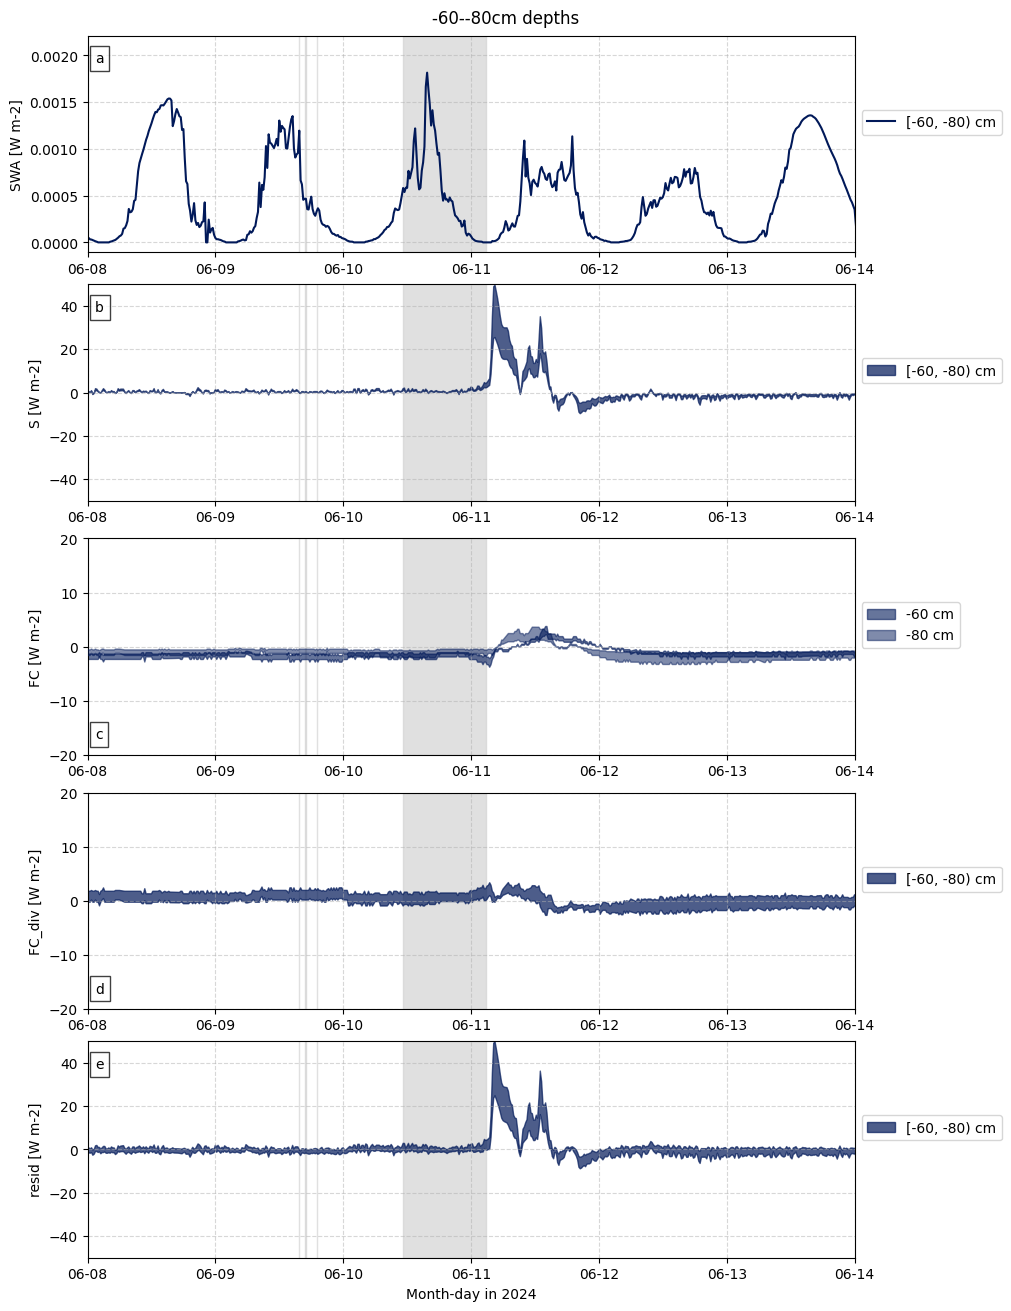

In [239]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

intervals_short = intervals[np.where(intervals<=-40)]
melt_colors_short = melt_colors[-len(intervals_short)+1:]
fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')

for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'{flx_key} [W m-2]')
    for n, (d0, d1) in enumerate(zip(intervals_short[:-1],intervals_short[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)], label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=f'{d0} cm', 
                                color=melt_colors_short[n])
            if d1==intervals_short[-1]:
                axs[i].fill_between(simba_dates, var_dic[d1]['lo'], 
                                var_dic[d1]['hi'], alpha=.5, label=f'{d1} cm', 
                                color=melt_colors_short[-1], zorder=5-n)
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    # ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    # ax.set_xlim(datetime.datetime(2024,5,24,5),datetime.datetime(2024,5,24,8))
    ax.set_xlim(datetime.datetime(2024,6,8),datetime.datetime(2024,6,14))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')
axs[1].set_ylim(-50,50)
axs[3].set_ylim(-20,20)
axs[2].set_ylim(-20,20)

axs[4].set_ylim(-50,50)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

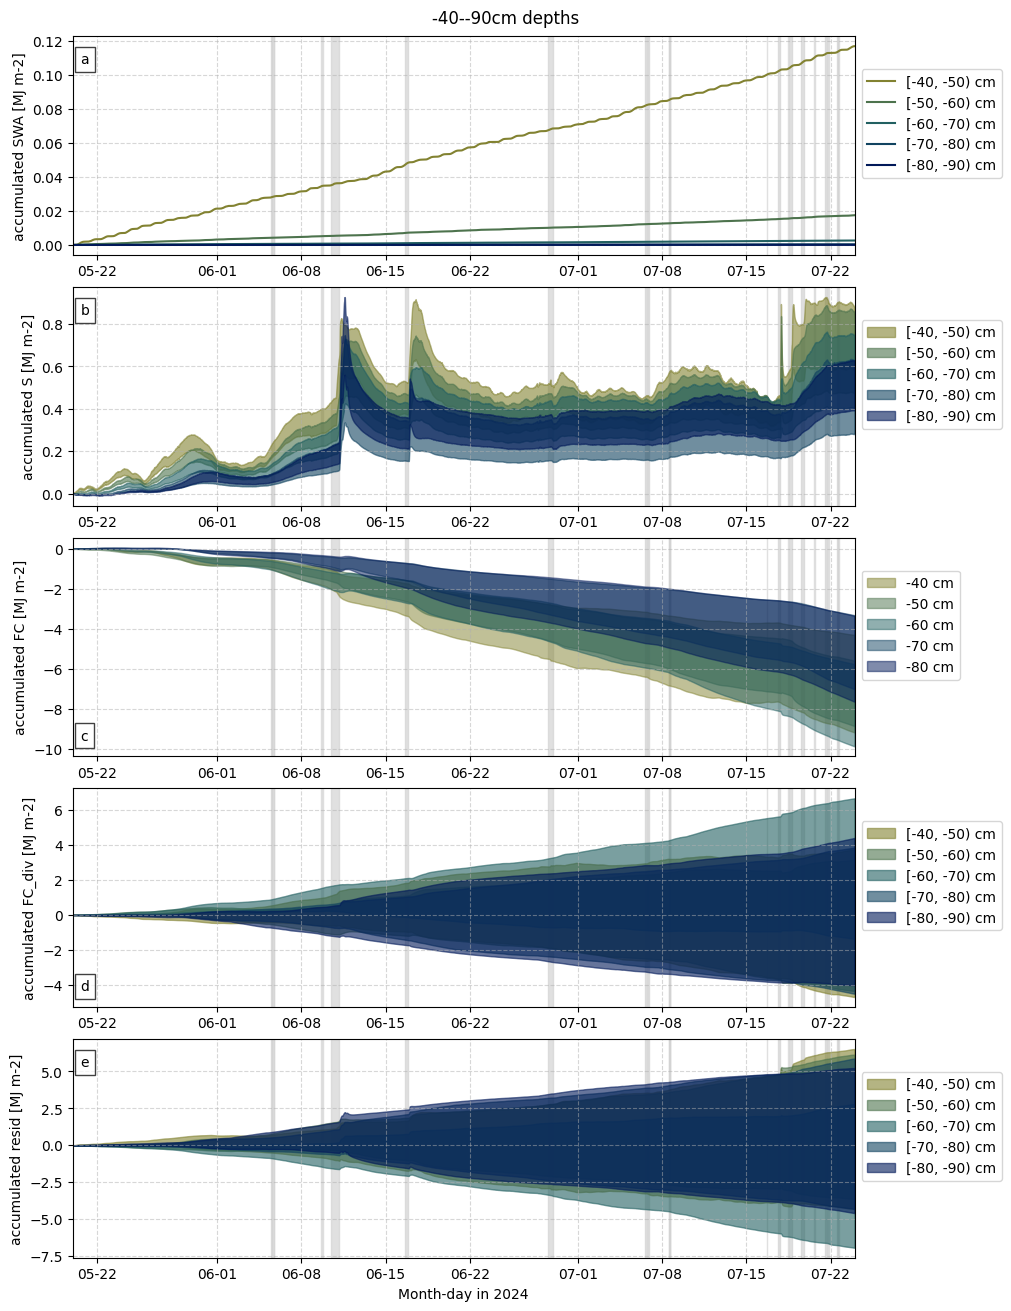

In [208]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

intervals_short = intervals[np.where(intervals<=-40)]
melt_colors_short = melt_colors[-len(intervals_short)+1:]

fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'accumulated {flx_key} [MJ m-2]')
    for n, (d0, d1) in enumerate(zip(intervals_short[:-1],intervals_short[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.6,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.6,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)].cumsum()*secs_in_obs/10**6, 
                            label=f'[{d0}, {d1}) cm', color=melt_colors_short[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'].cumsum()*secs_in_obs/10**6, 
                                var_dic[d0]['hi'].cumsum()*secs_in_obs/10**6, alpha=.5, label=f'{d0} cm', 
                                color=melt_colors_short[n])
            
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

# axs[2].set_ylim(-40,40)
# axs[3].set_ylim(-10,10)
# axs[4].set_ylim(-20,30)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

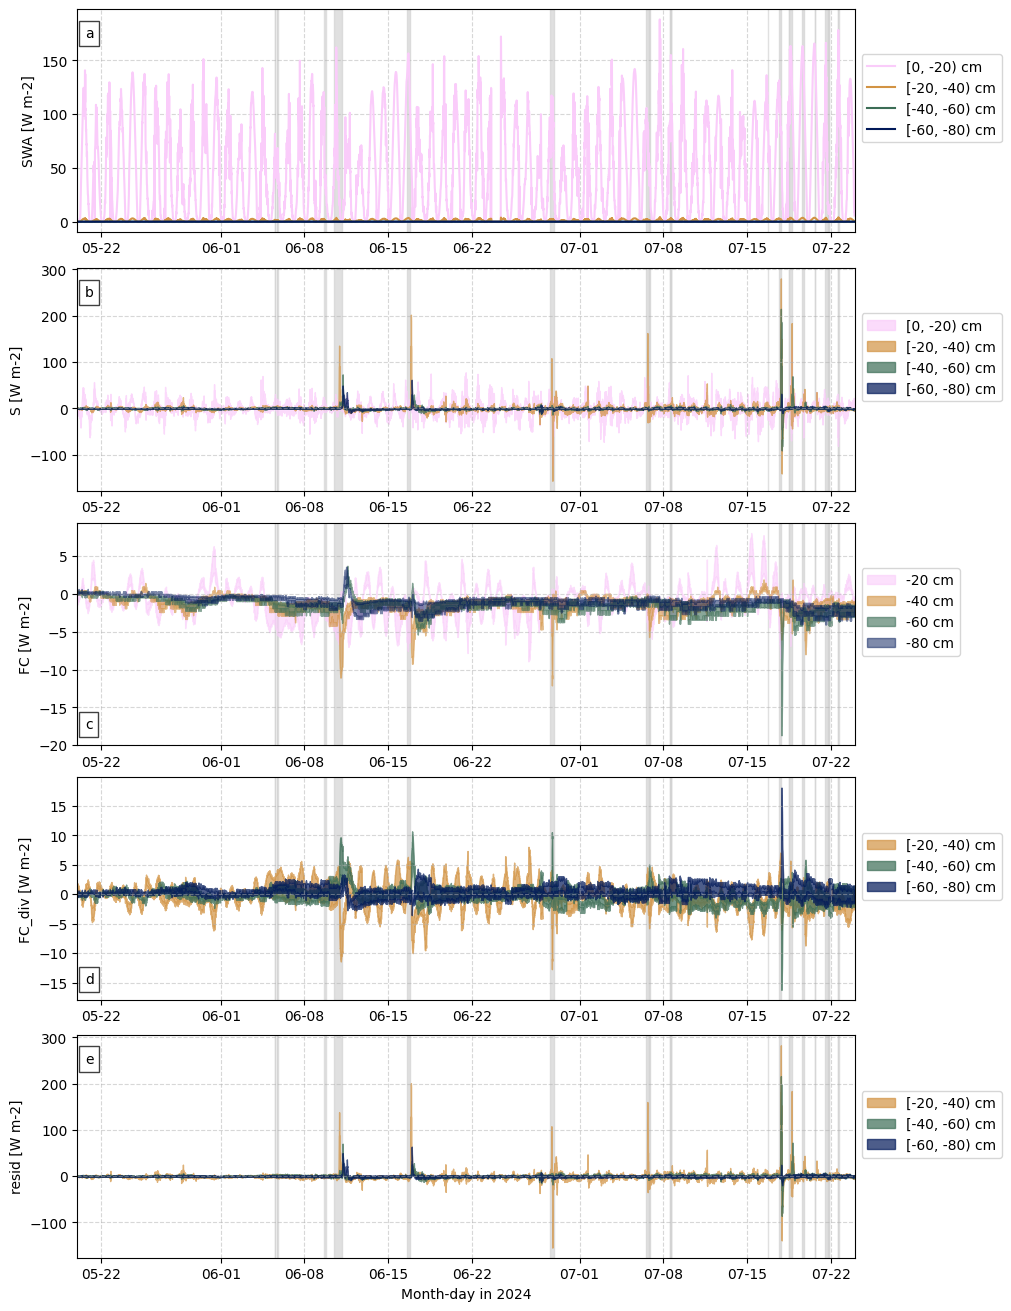

In [251]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

# intervals_short = intervals[np.where(intervals>=-50)]

# melt_colors_short = melt_colors[:len(intervals_short)]
# fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'{flx_key} [W m-2]')
    for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)], label=f'[{d0}, {d1}) cm', color=melt_colors[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=f'{d0} cm', 
                                color=melt_colors[n-1])
            if d1==intervals[-1]:
                axs[i].fill_between(simba_dates, var_dic[d1]['lo'], 
                                var_dic[d1]['hi'], alpha=.5, label=f'{d1} cm', 
                                color=melt_colors[n], zorder=5-n)
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    # ax.set_xlim(datetime.datetime(2024,6,2),datetime.datetime(2024,6,14))
    # ax.set_xlim(datetime.datetime(2024,6,18),datetime.datetime(2024,7,24))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

# axs[1].set_ylim(-40,40)
# axs[3].set_ylim(-20,20)
# axs[2].set_ylim(-10,5)

# axs[4].set_ylim(-60,60)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

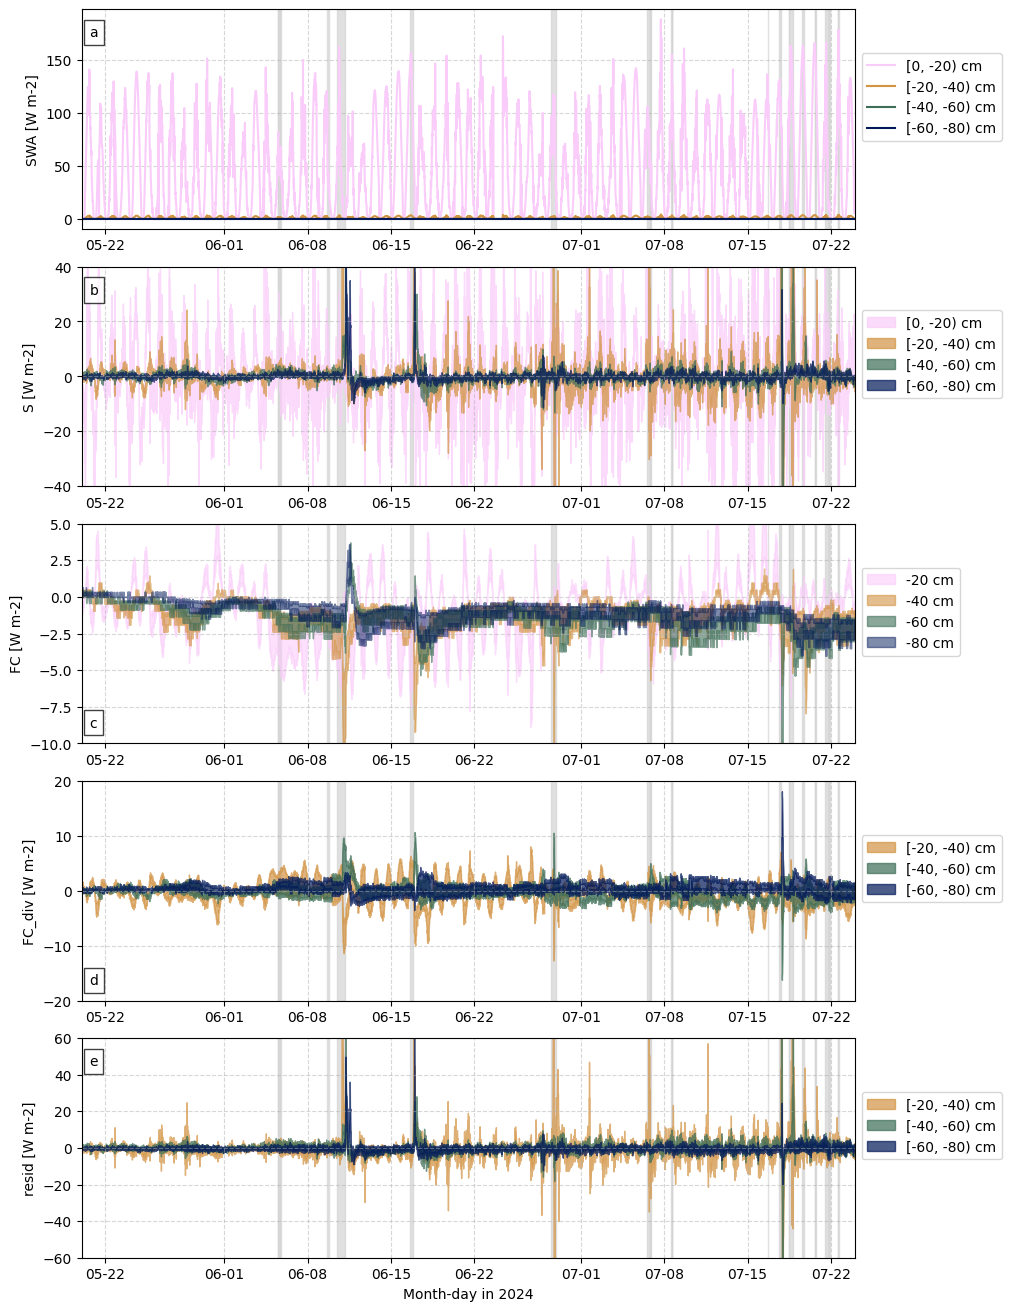

In [252]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)

# intervals_short = intervals[np.where(intervals>=-50)]

# melt_colors_short = melt_colors[:len(intervals_short)]
# fig.suptitle(f'{intervals_short[0]}-{intervals_short[-1]}cm depths')


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'{flx_key} [W m-2]')
    for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n])
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'], var_dic[d0,d1]['hi'], alpha=.7,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n])
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)], label=f'[{d0}, {d1}) cm', color=melt_colors[n])
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'], var_dic[d0]['hi'], alpha=.6, label=f'{d0} cm', 
                                color=melt_colors[n-1])
            if d1==intervals[-1]:
                axs[i].fill_between(simba_dates, var_dic[d1]['lo'], 
                                var_dic[d1]['hi'], alpha=.5, label=f'{d1} cm', 
                                color=melt_colors[n], zorder=5-n)
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))
    # ax.set_xlim(datetime.datetime(2024,6,2),datetime.datetime(2024,6,14))
    # ax.set_xlim(datetime.datetime(2024,6,18),datetime.datetime(2024,7,24))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

axs[1].set_ylim(-40,40)
axs[3].set_ylim(-20,20)
axs[2].set_ylim(-10,5)

axs[4].set_ylim(-60,60)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

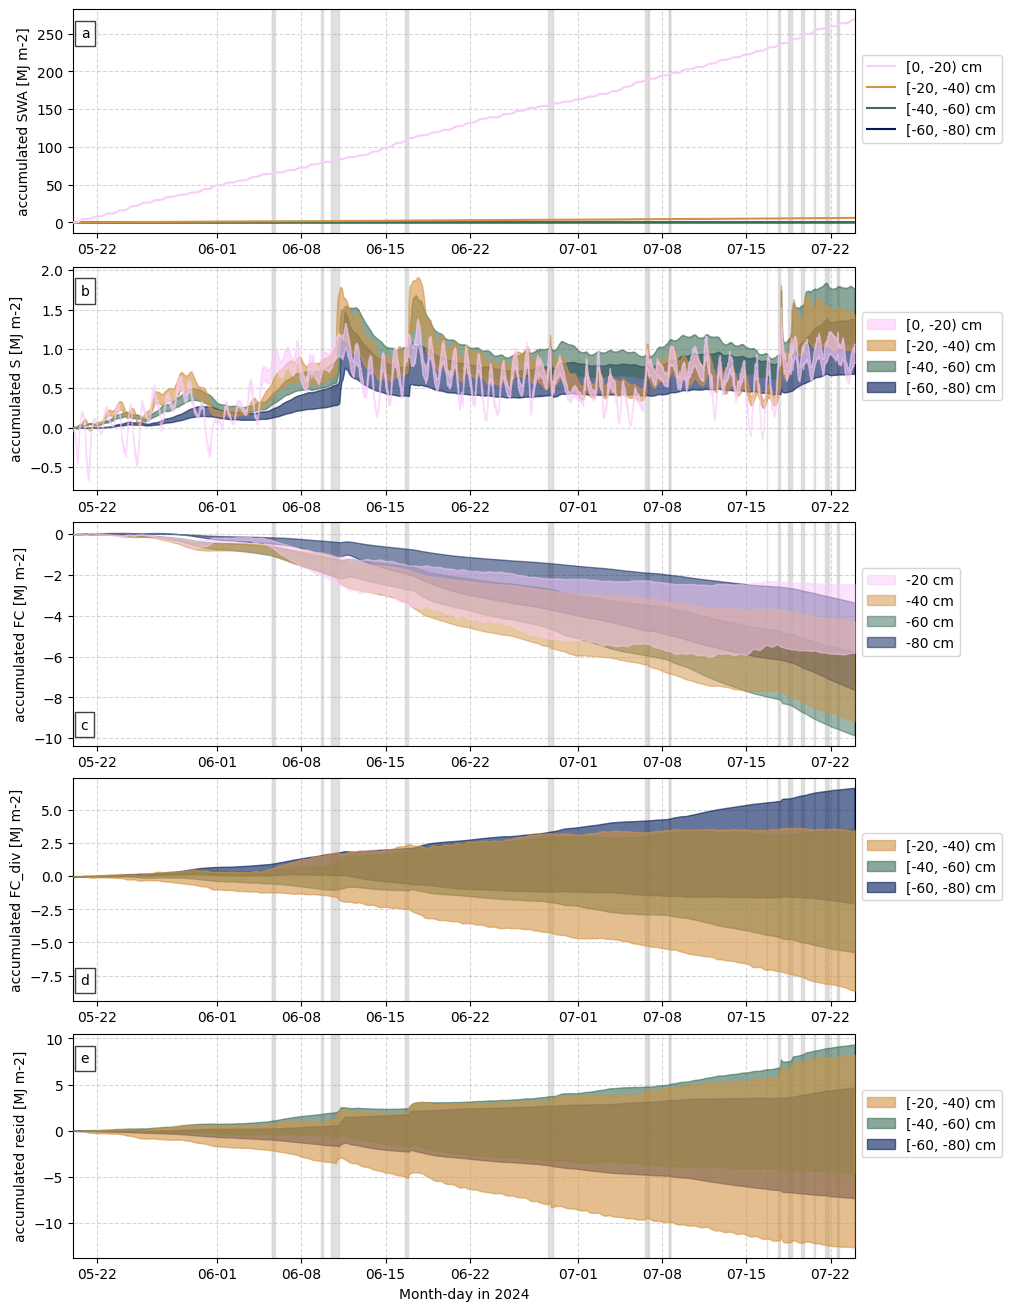

In [249]:
fig, axs = plt.subplots(5, figsize=(10,13), constrained_layout=True)


for i, flx_key in enumerate(interval_flx_dics):
    if '_sw' in flx_key:
        continue
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'accumulated {flx_key} [MJ m-2]')
    for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.6,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n], zorder=5-n)
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.6,
                                       label=f'[{d0}, {d1}) cm', color=melt_colors[n], zorder=5-n)
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)].cumsum()*secs_in_obs/10**6, 
                            label=f'[{d0}, {d1}) cm', color=melt_colors[n], zorder=5-n)
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'].cumsum()*secs_in_obs/10**6, 
                                var_dic[d0]['hi'].cumsum()*secs_in_obs/10**6, alpha=.5, label=f'{d0} cm', 
                                color=melt_colors[n-1], zorder=5-n)
            if d1==intervals[-1]:
                axs[i].fill_between(simba_dates, var_dic[d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                var_dic[d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.5, label=f'{d1} cm', 
                                color=melt_colors[n], zorder=5-n)
        # some levels aren't in the dictionary
        else:
            continue



for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    # ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))
    ax.set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))

    for melt_ind in tskin_melt_indices:
        ax.axvspan(simba_dates[melt_ind][0], simba_dates[melt_ind][-1], alpha=0.7, color='lightgray', zorder=0)
    
axs[-1].set_xlabel('Month-day in 2024')

# axs[2].set_ylim(-40,40)
# axs[3].set_ylim(-10,10)
# axs[4].set_ylim(-20,30)

labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

/tmp/ipykernel_3359360/2225449999.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1,.6))


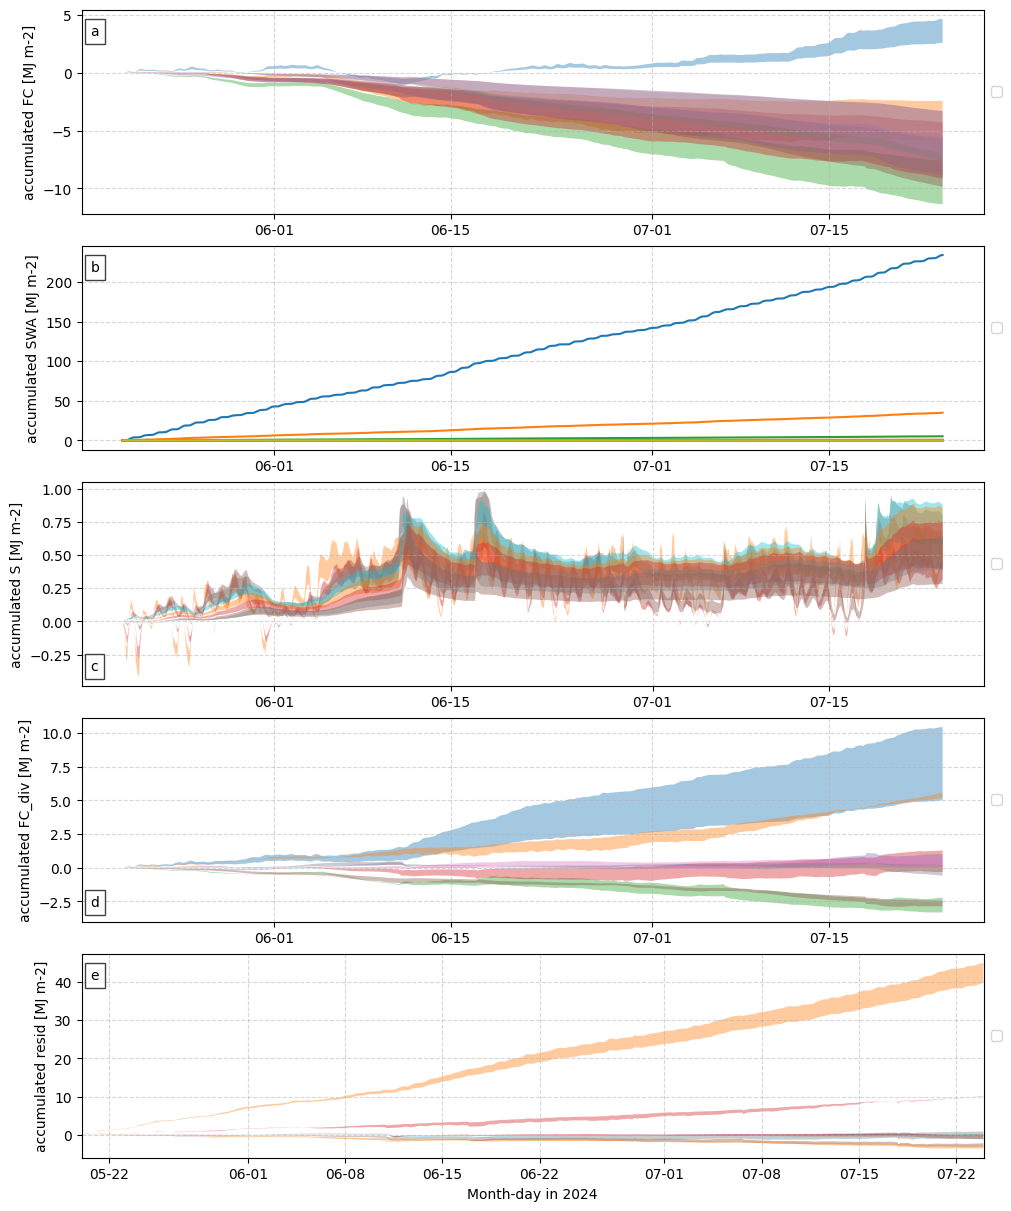

In [87]:
fig, axs = plt.subplots(5, figsize=(10,12), constrained_layout=True)

for i, flx_key in enumerate(interval_flx_dics):
    var_dic = interval_flx_dics[flx_key]
    axs[i].set_ylabel(f'accumulated {flx_key} [MJ m-2]')

    for n, (d0, d1) in enumerate(zip(intervals[:-1],intervals[1:])):
        
        # for variables that are calculated over an interval (FC_div, SWA, storage)
        if (d0,d1) in var_dic:
            if 'hi' in var_dic[(d0,d1)]:
                try:
                    axs[i].fill_between(simba_dates, var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.4)
                except:
                    axs[i].fill_between(simba_dates[1:-1], var_dic[d0,d1]['lo'].cumsum()*secs_in_obs/10**6, 
                                        var_dic[d0,d1]['hi'].cumsum()*secs_in_obs/10**6, alpha=.4)
            else:
                axs[i].plot(simba_dates, var_dic[(d0,d1)].cumsum()*secs_in_obs/10**6)
                
        # FC is only at a specific level
        elif d0 in var_dic:
            axs[i].fill_between(simba_dates, var_dic[d0]['lo'].cumsum()*secs_in_obs/10**6, 
                                var_dic[d0]['hi'].cumsum()*secs_in_obs/10**6, alpha=.4)
            
        # some levels aren't in the dictionary
        else:
            continue

# fix ylabels!!!

for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='center left', bbox_to_anchor=(1,.6))

    
axs[-1].set_xlabel('Month-day in 2024')
axs[-1].set_xlim(datetime.datetime(2024,5,20),datetime.datetime(2024,7,24))


labels = ['a','b','c','d','e']
xpos = []
ypos = [.875, .875, .075, .075, .875]
for i, ax in enumerate(axs.ravel()):
    ax.text(.01, ypos[i], labels[i], transform=ax.transAxes, fontsize=10,
       bbox=dict(facecolor='w', alpha=.75, edgecolor='k',))# pad=10.0))
plt.show()

## unclear what below was for

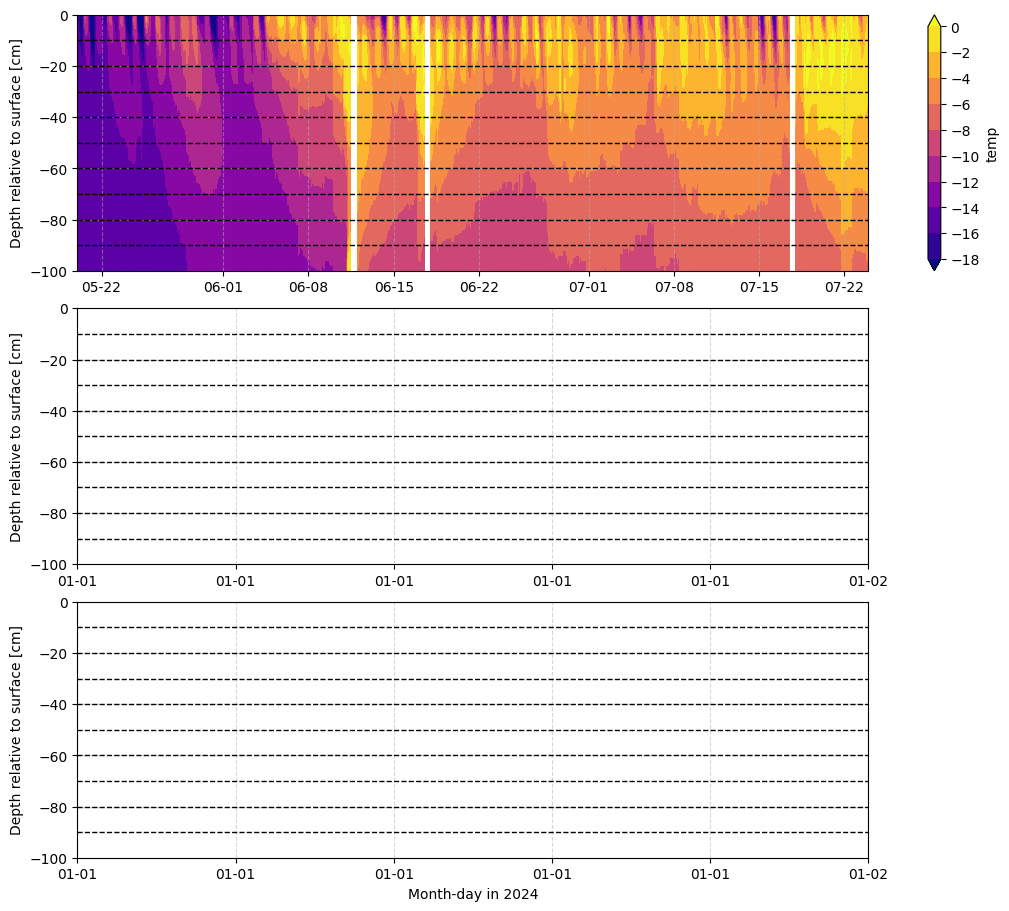

In [71]:
fig, axs = plt.subplots(3, figsize=(10,9), constrained_layout=True)

cb = axs[0].contourf(simba_dates, depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma',
                    levels=np.arange(-18,1,2), extend='both')
plt.colorbar(cb, ax=axs[0], label='temp')

# cb = axs[1].contourf(simba_dates, depth_rel_sfc, np.swapaxes(dT_dz_rel_to_sfc,0,1), cmap=cmocean.cm.curl, 
#                   levels=np.arange(-1,1.01,.1), extend='both')
# plt.colorbar(cb, ax=axs[1], label='dT/dz')

# cb = axs[2].contourf(simba_dates[1:-1], depth_rel_sfc, np.swapaxes(dTdt_storage_vers_rel_to_sfc,0,1), cmap=cmocean.cm.balance,
#                     levels=np.arange(-1,1.01,.1), extend='both')
# plt.colorbar(cb, ax=axs[2], label='dT/dt')

for ax in axs.ravel():
    ax.set_ylabel('Depth relative to surface [cm]')
    for d in range(-10,-91,-10):
        ax.axhline(y=d, ls='--', c='k', lw=1)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(-100,0)
    ax.xaxis.set_major_formatter(myFmt)
axs[-1].set_xlabel('Month-day in 2024')
# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

In [68]:
def generate_slab_intervals(top_lev_in, lowest_lev_in, slab_thickness_in):
    return np.arange(-top_lev_in,-(lowest_lev_in+1),-slab_thickness_in)

In [72]:
slab_thickness = 10 #cm
top_lev = 0
lowest_lev = 40

intervals = generate_slab_intervals(top_lev,lowest_lev, slab_thickness) # lowest level is about where there are obs for entire season

for n, (i0, i1) in enumerate(zip(intervals[:-1],intervals[1:])):
    int_idx = np.where((depth_rel_sfc<=i0)&(depth_rel_sfc>i1))[0]
    int_temp = temps_rel_sfc[:, int_idx]
    # print(i0, i1, int_temp.shape, int_temp.mean(axis=1).shape)
    interval_temps[(i0, i1)] = int_temp.mean(axis=1)


    int_dTdz = dTdz_rel_sfc[:,np.where(depth_rel_sfc==i0)[0]]
    axs[1].plot(simba_dates, int_dTdz, label=f'{i0} cm', c=color_list[n])

NameError: name 'interval_temps' is not defined